# Reto MA2003B - Calidad del Aire y Contaminantes ZMM
- Gabriel Villanueva de Araujo Souza - A01781585
- Hildegard Zerrweck García - A00838300
- Julio Chárbel Porras Osorio - A01736268

In [3]:
# Librerías optimizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scipy
from scipy.stats import yeojohnson, kstest, norm

# Statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


import re

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


# LIMPIEZA

## Compilación Datos no Limpios

In [26]:

base = Path("/Users/gabrielvas/Desktop/Aplicacion_metodosmultivariados_Reto")
stations = ["CENTRO", "SUROESTE2", "SURESTE3", "NORTE2"]
year_files = {
    2022: base / "DATOS_HISTORICOS_2022.xlsx",
    2023: base / "DATOS_HISTORICOS_2023.xlsx",
    2024: base / "DATOS_HISTORICOS_2024.xlsx",
    2025: base / "DATOS_HISTORICOS_2025.xlsx",
}

raw_series = {station: [] for station in stations}


for year, file in year_files.items():
    yearly_raw = pd.read_excel(file, sheet_name=stations)  # sin limpieza
    for station in stations:
        df_station = yearly_raw[station].copy()
        # Eliminar columnas 'RAINF', 'RH', 'PRS' si existen
        df_station = df_station #.drop(columns=[col for col in columns_to_drop if col in df_station.columns], errors='ignore')
        df_station["date"] = pd.to_datetime(df_station["date"])
        df_station = df_station.set_index("date").sort_index()
        df_station["year"] = year           # opcional, ayuda a rastrear el origen
        raw_series[station].append(df_station)

df_por_estacion = {
    station: pd.concat(raw_series[station], axis=0)
    for station in stations
}

globals().update({
    f"df_{station}_22_25_nolimpio": df_por_estacion[station]
    for station in stations
})

# Ejemplo de verificación
for station in stations:
    print(station, df_por_estacion[station].shape)

CENTRO (30646, 16)
SUROESTE2 (30643, 16)
SURESTE3 (30643, 16)
NORTE2 (30644, 16)


## Datos Limpios

### 2022

In [27]:
# ============================
# 1. CARGAR DATOS
# ============================

raw_data = pd.read_excel(
    "DATOS_HISTORICOS_2022.xlsx",
    sheet_name=stations
)

# Remover columnas que no usarás
for name in stations:
    raw_data[name] = raw_data[name].drop(columns=["RAINF","WDR","NO","NO2"])

# ============================
# 2. RANGOS PERMITIDOS
# ============================

ranges = {
    "NOX": (0, 420),
    "O3": (0, 160),
    "PM10": (0, 999),
    "PM2.5": (0, 450),
    "SO2": (0, 200),
    "SR": (0, 1.25),
    "TOUT": (-5, 45),
    "WSR": (0, 35),
    "RH": (0, 100),
    "SR": (0, 1.25),
    "PRS": (700,740),
}

# ============================
# 3. FUNCIÓN: ELIMINAR FUERA DE RANGO
# ============================

def clean_out_of_range(df):
    for col, (low, high) in ranges.items():
        if col in df.columns:
            df.loc[(df[col] < low) | (df[col] > high), col] = np.nan
    return df

# ============================
# 4. FUNCIÓN: IMPUTACIÓN COMPLETA
# ============================

def impute_df(df):

    # Asegurar índice de tiempo
    df.index = pd.to_datetime(df.index)

    # ----------------------------
    # Gases reactivos — interpolación temporal
    # ----------------------------
    gases_time = ["CO", "NO", "NO2", "NOX", "O3", "SO2"]
    for col in gases_time:
        if col in df.columns:
            df[col] = df[col].interpolate(method="time")

    # ----------------------------
    # Material particulado
    # ----------------------------
    if "PM10" in df.columns:
        df["PM10"] = df["PM10"].interpolate(method="linear")

    if "PM2.5" in df.columns:
        df["PM2.5"] = df["PM2.5"].interpolate(method="linear")

    # ----------------------------
    # Meteorológicas suaves
    # ----------------------------
    if "TOUT" in df.columns:
        df["TOUT"] = df["TOUT"].interpolate(method="time")

    # Imputación de RH (Humedad Relativa)
    if "RH" in df.columns:
        df["RH"] = df["RH"].interpolate(method="time")

    # Imputación de SR (Radiación Solar)
    if "SR" in df.columns:
        df["SR"] = df["SR"].interpolate(method="time")

    # Imputación de PRS (Presión)
    if "PRS" in df.columns:
        df["PRS"] = df["PRS"].interpolate(method="time")

    # ----------------------------
    # Velocidad del viento — mediana móvil
    # ----------------------------
    if "WSR" in df.columns:
        df["WSR"] = df["WSR"].fillna(df["WSR"].rolling(5, min_periods=1).median())

    # ----------------------------
    # Limpieza final
    # ----------------------------
    df = df.ffill().bfill()
    df = df.round(2)

    return df

# ============================
# 5. PROCESAR CADA SHEET Y CREAR DF FINAL
# ============================

for name in stations:
    temp_df = raw_data[name].copy()

    # Usar fecha como índice
    temp_df["date"] = pd.to_datetime(temp_df["date"])
    temp_df = temp_df.set_index("date")

    # Quitar valores fuera de rango
    temp_df = clean_out_of_range(temp_df)

    temp_df = impute_df(temp_df)

    # Crear la variable global df_2022_NOMBRE
    globals()[f"df_2022_{name}"] = temp_df

    print(f"Listo: df_2022_{name} creado (shape={temp_df.shape})")

print("\n--- PROCESO COMPLETO ---")


Listo: df_2022_CENTRO creado (shape=(8760, 11))
Listo: df_2022_SUROESTE2 creado (shape=(8760, 11))
Listo: df_2022_SURESTE3 creado (shape=(8760, 11))
Listo: df_2022_NORTE2 creado (shape=(8760, 11))

--- PROCESO COMPLETO ---


### 2023

In [28]:
# ============================
# 1. CARGAR DATOS
# ============================

raw_data = pd.read_excel(
    "DATOS_HISTORICOS_2023.xlsx",
    sheet_name=stations
)

# Remover columnas que no usarás
for name in stations:
    raw_data[name] = raw_data[name].drop(columns=["RAINF","WDR","NO","NO2"])

# ============================
# 2. RANGOS PERMITIDOS
# ============================

ranges = {
    "NOX": (0, 500),
    "O3": (0, 175),
    "PM10": (0, 900),
    "PM2.5": (0, 800),
    "SO2": (0, 250),
    "SR": (0, 1.25),
    "TOUT": (0, 45),
    "WSR": (0, 40),
    "RH": (0, 100),
    "SR": (0, 1),
    "PRS": (690,740),
}

# ============================
# 3. FUNCIÓN: ELIMINAR FUERA DE RANGO
# ============================

def clean_out_of_range(df):
    for col, (low, high) in ranges.items():
        if col in df.columns:
            df.loc[(df[col] < low) | (df[col] > high), col] = np.nan
    return df

# ============================
# 4. FUNCIÓN: IMPUTACIÓN COMPLETA
# ============================

def impute_df(df):

    # Asegurar índice de tiempo
    df.index = pd.to_datetime(df.index)

    # ----------------------------
    # Gases reactivos — interpolación temporal
    # ----------------------------
    gases_time = ["CO", "NO", "NO2", "NOX", "O3", "SO2"]
    for col in gases_time:
        if col in df.columns:
            df[col] = df[col].interpolate(method="time")

    # ----------------------------
    # Material particulado
    # ----------------------------
    if "PM10" in df.columns:
        df["PM10"] = df["PM10"].interpolate(method="linear")

    if "PM2.5" in df.columns:
        df["PM2.5"] = df["PM2.5"].interpolate(method="linear")

    # ----------------------------
    # Meteorológicas suaves
    # ----------------------------
    if "TOUT" in df.columns:
        df["TOUT"] = df["TOUT"].interpolate(method="time")

    # Imputación de RH (Humedad Relativa)
    if "RH" in df.columns:
        df["RH"] = df["RH"].interpolate(method="time")

    # Imputación de SR (Radiación Solar)
    if "SR" in df.columns:
        df["SR"] = df["SR"].interpolate(method="time")

    # Imputación de PRS (Presión)
    if "PRS" in df.columns:
        df["PRS"] = df["PRS"].interpolate(method="time")

    # ----------------------------
    # Velocidad del viento — mediana móvil
    # ----------------------------
    if "WSR" in df.columns:
        df["WSR"] = df["WSR"].fillna(df["WSR"].rolling(5, min_periods=1).median())

    # ----------------------------
    # Limpieza final
    # ----------------------------
    df = df.ffill().bfill()
    df = df.round(2)

    return df

# ============================
# 5. PROCESAR CADA SHEET Y CREAR DF FINAL
# ============================

for name in stations:
    temp_df = raw_data[name].copy()

    # Usar fecha como índice
    temp_df["date"] = pd.to_datetime(temp_df["date"])
    temp_df = temp_df.set_index("date")

    # Quitar valores fuera de rango
    temp_df = clean_out_of_range(temp_df)

    temp_df = impute_df(temp_df)

    # Crear la variable global df_2022_NOMBRE
    globals()[f"df_2023_{name}"] = temp_df

    print(f"Listo: df_2023_{name} creado (shape={temp_df.shape})")

print("\n--- PROCESO COMPLETO ---")

Listo: df_2023_CENTRO creado (shape=(8758, 11))
Listo: df_2023_SUROESTE2 creado (shape=(8758, 11))
Listo: df_2023_SURESTE3 creado (shape=(8758, 11))
Listo: df_2023_NORTE2 creado (shape=(8758, 11))

--- PROCESO COMPLETO ---


### 2024

In [29]:
# ============================
# 1. CARGAR DATOS
# ============================

raw_data = pd.read_excel(
    "DATOS_HISTORICOS_2024.xlsx",
    sheet_name=stations
)

# Remover columnas que no usarás
for name in stations:
    raw_data[name] = raw_data[name].drop(columns=["RAINF","WDR","NO","NO2"])

# ============================
# 2. RANGOS PERMITIDOS
# ============================

ranges = {
    "NOX": (0, 500),
    "O3": (0, 180),
    "PM10": (0, 999),
    "PM2.5": (0, 999),
    "SO2": (0, 150),
    "SR": (0, 1.25),
    "TOUT": (-4, 45.5),
    "WSR": (0, 38),
    "RH": (0, 100),
    "SR": (0, 1.26),
    "PRS": (687.5,740),
}

# ============================
# 3. FUNCIÓN: ELIMINAR FUERA DE RANGO
# ============================

def clean_out_of_range(df):
    for col, (low, high) in ranges.items():
        if col in df.columns:
            df.loc[(df[col] < low) | (df[col] > high), col] = np.nan
    return df

# ============================
# 4. FUNCIÓN: IMPUTACIÓN COMPLETA
# ============================

def impute_df(df):

    # Asegurar índice de tiempo
    df.index = pd.to_datetime(df.index)

    # ----------------------------
    # Gases reactivos — interpolación temporal
    # ----------------------------
    gases_time = ["CO", "NO", "NO2", "NOX", "O3", "SO2"]
    for col in gases_time:
        if col in df.columns:
            df[col] = df[col].interpolate(method="time")

    # ----------------------------
    # Material particulado
    # ----------------------------
    if "PM10" in df.columns:
        df["PM10"] = df["PM10"].interpolate(method="linear")

    if "PM2.5" in df.columns:
        df["PM2.5"] = df["PM2.5"].interpolate(method="linear")

    # ----------------------------
    # Meteorológicas suaves
    # ----------------------------
    if "TOUT" in df.columns:
        df["TOUT"] = df["TOUT"].interpolate(method="time")

    # Imputación de RH (Humedad Relativa)
    if "RH" in df.columns:
        df["RH"] = df["RH"].interpolate(method="time")

    # Imputación de SR (Radiación Solar)
    if "SR" in df.columns:
        df["SR"] = df["SR"].interpolate(method="time")

    # Imputación de PRS (Presión)
    if "PRS" in df.columns:
        df["PRS"] = df["PRS"].interpolate(method="time")

    # ----------------------------
    # Velocidad del viento — mediana móvil
    # ----------------------------
    if "WSR" in df.columns:
        df["WSR"] = df["WSR"].fillna(df["WSR"].rolling(5, min_periods=1).median())

    # ----------------------------
    # Limpieza final
    # ----------------------------
    df = df.ffill().bfill()
    df = df.round(2)

    return df

# ============================
# 5. PROCESAR CADA SHEET Y CREAR DF FINAL
# ============================

for name in stations:
    temp_df = raw_data[name].copy()

    # Usar fecha como índice
    temp_df["date"] = pd.to_datetime(temp_df["date"])
    temp_df = temp_df.set_index("date")

    # Quitar valores fuera de rango
    temp_df = clean_out_of_range(temp_df)

    temp_df = impute_df(temp_df)

    # Crear la variable global 
    globals()[f"df_2024_{name}"] = temp_df

    print(f"Listo: df_2024_{name} creado (shape={temp_df.shape})")

print("\n--- PROCESO COMPLETO ---")

Listo: df_2024_CENTRO creado (shape=(8784, 11))
Listo: df_2024_SUROESTE2 creado (shape=(8782, 11))
Listo: df_2024_SURESTE3 creado (shape=(8782, 11))
Listo: df_2024_NORTE2 creado (shape=(8782, 11))

--- PROCESO COMPLETO ---


### 2025

In [30]:
# ============================
# 1. CARGAR DATOS
# ============================

raw_data = pd.read_excel(
    "DATOS_HISTORICOS_2024.xlsx",
    sheet_name=stations
)

# Remover columnas que no usarás
for name in stations:
    raw_data[name] = raw_data[name].drop(columns=["RAINF","WDR","NO","NO2"])

# ============================
# 2. RANGOS PERMITIDOS
# ============================

ranges = {
    "NOX": (0, 400),
    "O3": (0, 185),
    "PM10": (0, 820),
    "PM2.5": (0, 350),
    "SO2": (0, 405),
    "SR": (0, 1.25),
    "TOUT": (-4.5, 45),
    "WSR": (0, 40),
    "RH": (0, 100),
    "SR": (0, 1.2),
    "PRS": (688,740),
}

# ============================
# 3. FUNCIÓN: ELIMINAR FUERA DE RANGO
# ============================

def clean_out_of_range(df):
    for col, (low, high) in ranges.items():
        if col in df.columns:
            df.loc[(df[col] < low) | (df[col] > high), col] = np.nan
    return df

# ============================
# 4. FUNCIÓN: IMPUTACIÓN COMPLETA
# ============================

def impute_df(df):

    # Asegurar índice de tiempo
    df.index = pd.to_datetime(df.index)

    # ----------------------------
    # Gases reactivos — interpolación temporal
    # ----------------------------
    gases_time = ["CO", "NO", "NO2", "NOX", "O3", "SO2"]
    for col in gases_time:
        if col in df.columns:
            df[col] = df[col].interpolate(method="time")

    # ----------------------------
    # Material particulado
    # ----------------------------
    if "PM10" in df.columns:
        df["PM10"] = df["PM10"].interpolate(method="linear")

    if "PM2.5" in df.columns:
        df["PM2.5"] = df["PM2.5"].interpolate(method="linear")

    # ----------------------------
    # Meteorológicas suaves
    # ----------------------------
    if "TOUT" in df.columns:
        df["TOUT"] = df["TOUT"].interpolate(method="time")

    # Imputación de RH (Humedad Relativa)
    if "RH" in df.columns:
        df["RH"] = df["RH"].interpolate(method="time")

    # Imputación de SR (Radiación Solar)
    if "SR" in df.columns:
        df["SR"] = df["SR"].interpolate(method="time")

    # Imputación de PRS (Presión)
    if "PRS" in df.columns:
        df["PRS"] = df["PRS"].interpolate(method="time")

    # ----------------------------
    # Velocidad del viento — mediana móvil
    # ----------------------------
    if "WSR" in df.columns:
        df["WSR"] = df["WSR"].fillna(df["WSR"].rolling(5, min_periods=1).median())

    # ----------------------------
    # Limpieza final
    # ----------------------------
    df = df.ffill().bfill()
    df = df.round(2)

    return df

# ============================
# 5. PROCESAR CADA SHEET Y CREAR DF FINAL
# ============================

for name in stations:
    temp_df = raw_data[name].copy()

    # Usar fecha como índice
    temp_df["date"] = pd.to_datetime(temp_df["date"])
    temp_df = temp_df.set_index("date")

    # Quitar valores fuera de rango
    temp_df = clean_out_of_range(temp_df)

    temp_df = impute_df(temp_df)

    # Crear la variable global 
    globals()[f"df_2025_{name}"] = temp_df

    print(f"Listo: df_2025_{name} creado (shape={temp_df.shape})")

print("\n--- PROCESO COMPLETO ---")

Listo: df_2025_CENTRO creado (shape=(8784, 11))
Listo: df_2025_SUROESTE2 creado (shape=(8782, 11))
Listo: df_2025_SURESTE3 creado (shape=(8782, 11))
Listo: df_2025_NORTE2 creado (shape=(8782, 11))

--- PROCESO COMPLETO ---


### Compilación Datos Limpiados

In [31]:
# Concatenar DataFrames por estación a través de 2022–2025

pattern = re.compile(r"^df_(2022|2023|2024|2025)_(.+)$")

frames_by_station: dict[str, list[tuple[int, pd.DataFrame]]] = {}
# Importante: iterar sobre una copia estática de globals() para evitar
# "RuntimeError: dictionary changed size during iteration"
for var_name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        m = pattern.match(var_name)
        if m:
            year = int(m.group(1))
            station = m.group(2)
            frames_by_station.setdefault(station, []).append((year, obj))

combined_by_station: dict[str, pd.DataFrame] = {}
for station, items in frames_by_station.items():
    # Ordenar por año
    items_sorted = sorted(items, key=lambda x: x[0])
    frames = [df for _, df in items_sorted]

    # Alinear columnas (unión en el primer orden encontrado)
    ordered_union_cols: list[str] = []
    seen_cols: set[str] = set()
    for df in frames:
        for c in df.columns:
            if c not in seen_cols:
                seen_cols.add(c)
                ordered_union_cols.append(c)

    aligned_frames = [df.reindex(columns=ordered_union_cols) for df in frames]
    combined_df = pd.concat(aligned_frames, sort=False)
    combined_df = combined_df.sort_index()

    var_name = f"df_{station}_22_25"  # Nota: guiones no válidos en nombres de variables
    globals()[var_name] = combined_df
    combined_by_station[station] = combined_df

    print(f"Creado {var_name}: shape={combined_df.shape} | años={[y for y, _ in items_sorted]}")

   # Guardar el DataFrame combinado a CSV
    try:
        combined_df.to_csv(f"{var_name}.csv")
        print(f" → Guardado como {var_name}.csv")
    except Exception as e:
        print(f"Error al guardar {var_name}.csv:", e)

# Acceso también vía diccionario
df_22_25_by_station = combined_by_station
print(f"\nEstaciones combinadas: {list(df_22_25_by_station.keys())}")


Creado df_CENTRO_22_25: shape=(35086, 11) | años=[2022, 2023, 2024, 2025]
 → Guardado como df_CENTRO_22_25.csv
Creado df_SUROESTE2_22_25: shape=(35082, 11) | años=[2022, 2023, 2024, 2025]
 → Guardado como df_SUROESTE2_22_25.csv
Creado df_SURESTE3_22_25: shape=(35082, 11) | años=[2022, 2023, 2024, 2025]
 → Guardado como df_SURESTE3_22_25.csv
Creado df_NORTE2_22_25: shape=(35082, 11) | años=[2022, 2023, 2024, 2025]
 → Guardado como df_NORTE2_22_25.csv

Estaciones combinadas: ['CENTRO', 'SUROESTE2', 'SURESTE3', 'NORTE2']


# ANÁLISIS MODELO ARIMA y ARIMAX

## URBANO

### CENTRO

In [10]:
# Crear un DataFrame de los promedios diarios para df_CENTRO_22_25
df_22_25_diario = df_CENTRO_22_25.copy()
df_22_25_diario.index = pd.to_datetime(df_22_25_diario.index)
df_22_25_diario = df_22_25_diario.resample("D").mean()
df_22_25_diario.describe().T

,count,mean,std,min,25%,50%,75%,max
CO,1277.0,1.579731,0.739820,0.158750,1.002917,1.442917,2.067083,3.680000
NO,1277.0,9.039865,8.336963,1.316667,4.516667,5.985417,10.537500,101.604167
NO2,1277.0,16.997600,7.975153,2.675000,11.112500,15.292083,21.750000,56.050000
O3,1277.0,28.350013,10.269592,1.197917,21.383333,27.750000,34.666667,64.340417
PM10,1277.0,61.025374,24.809355,11.858333,43.958333,56.125000,72.958333,212.687500
PM2.5,1277.0,24.727508,11.784931,5.013333,16.032083,22.755417,31.275417,87.355000
PRS,1277.0,711.363798,3.416821,696.179167,709.191667,711.100000,713.337500,723.066667
RH,1277.0,54.335992,16.107559,7.000000,43.875000,54.375000,64.958333,94.000000
SO2,1277.0,4.665779,1.904199,1.547500,3.212500,4.420833,5.858333,20.920833
SR,1277.0,0.183104,0.083548,0.000000,0.134167,0.186250,0.240833,0.625417


#### ACF

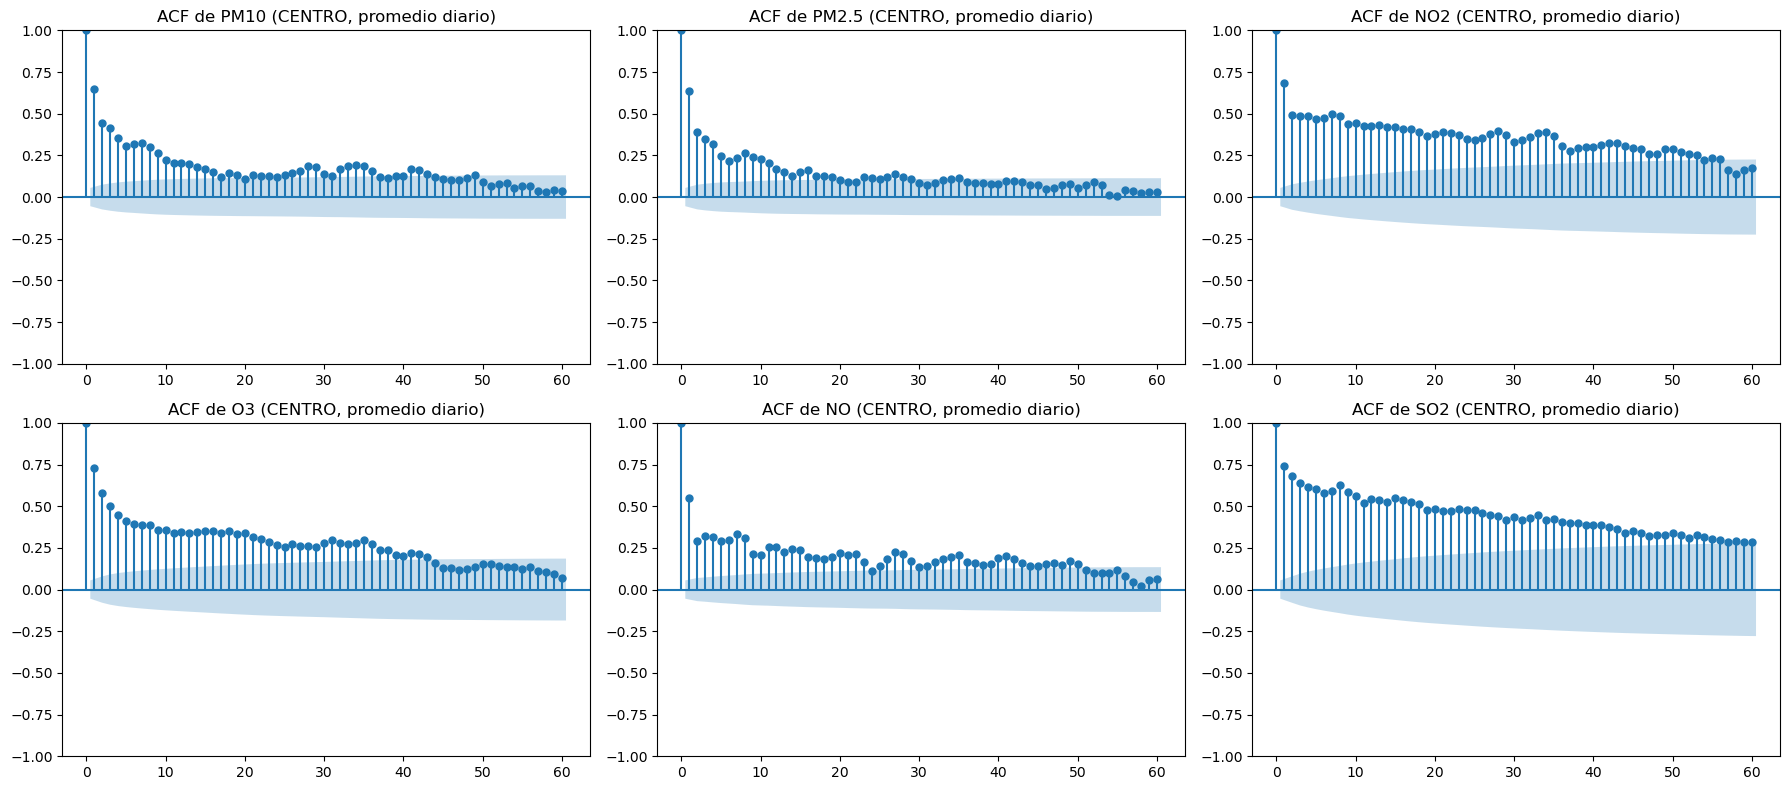

In [11]:
variables_analizar = ["PM10", "PM2.5", "NO2", "O3", "NO", "SO2"]

nrows, ncols = 2, 3  # 3 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()  # aplanar para indexado sencillo

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_22_25_diario.columns:
        serie = df_22_25_diario[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)
        ax.set_title(f"ACF de {var} (CENTRO, promedio diario)")
    else:
        ax.set_visible(False)

# Oculta ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


Los niveles diarios de todos estos contaminantes en la estación CENTRO no son independientes de un día a otro; muestran fuerte dependencia temporal y persistencia. Es decir, si un día hay niveles altos/bajos, es muy probable que en los días siguientes sigan siendo parecidos, y ese efecto puede durar varias semanas. Esto indica que las series son claramente no aleatorias y probablemente no estacionarias

#### PACF

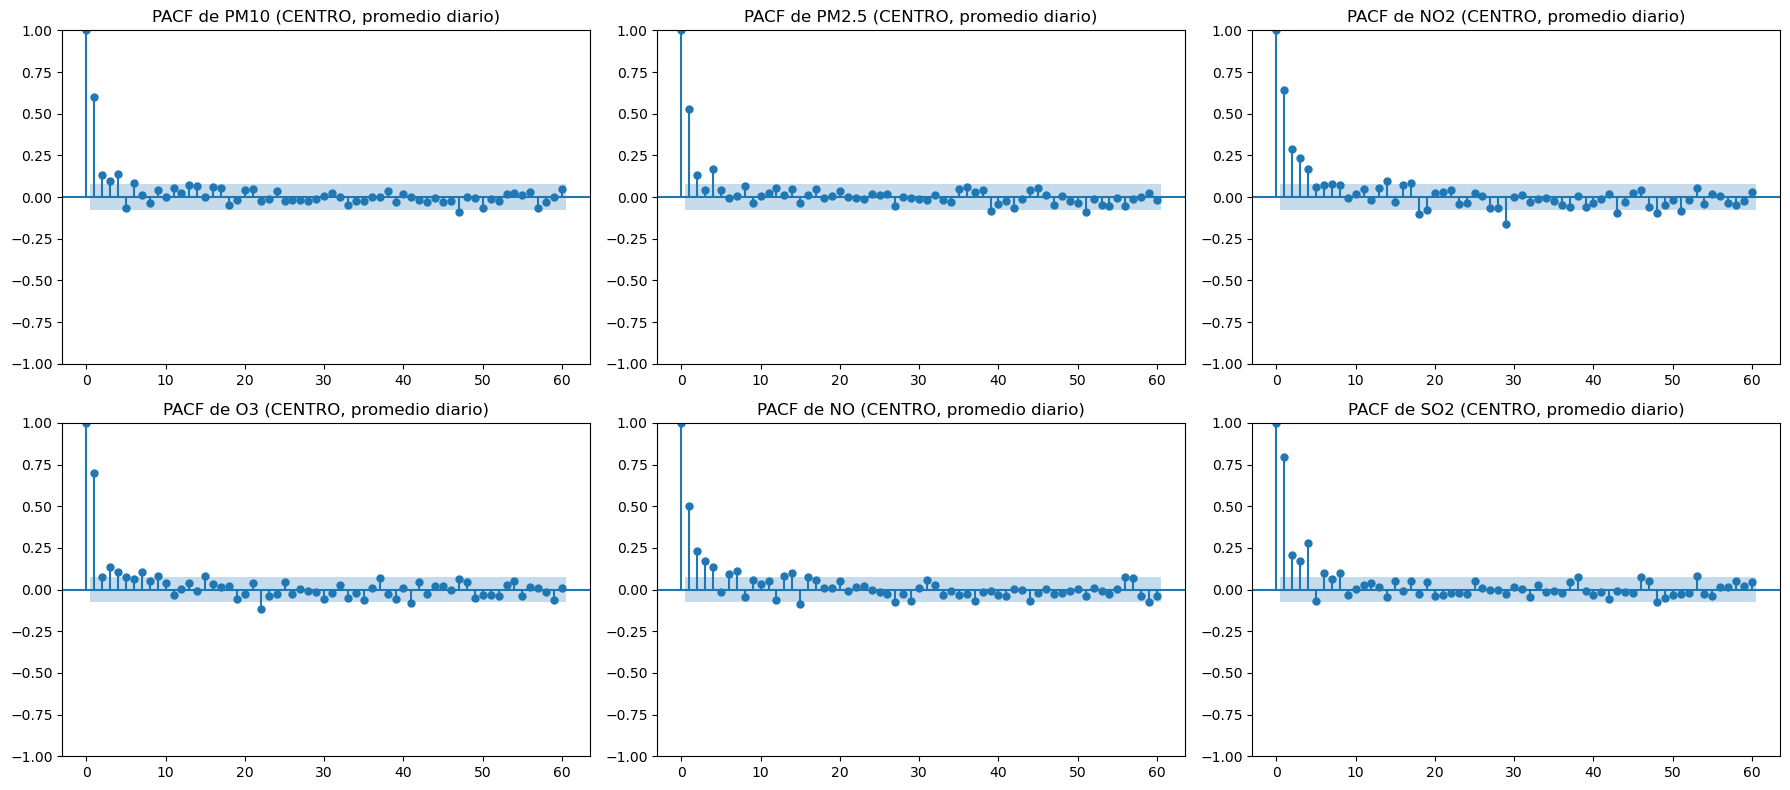

In [38]:
variables_analizar = ["PM10", "PM2.5", "NO2", "O3", "NO", "SO2"]

nrows, ncols = 2, 3  # 3 columnas x 2 filas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_22_25_diario.columns:
        serie = df_22_25_diario[var].dropna()
        # Calcular máximo nlags permitido para el tamaño de muestra actual
        max_lags = int((len(serie)) // 2) - 1
        safe_lags = min(max_lags, 60)  # normalmente 60, pero nunca más del permitido
        if safe_lags < 1:
            ax.set_visible(False)
            continue
        plot_pacf(serie, ax=ax, lags=safe_lags, alpha=0.05, method='ywm')
        ax.set_title(f"PACF de {var} (CENTRO, promedio diario)")
    else:
        ax.set_visible(False)

# Ocultar ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


Los contaminantes diarios del CENTRO muestran que el valor de hoy depende principalmente del valor de 1 día antes (y muy poco de días más antiguos); para un modelo ARIMA, la PACF sugiere usar p ≈ 1 en la parte autorregresiva.

#### Modelo

In [ ]:
# --- Configuración Inicial ---
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

import os

contaminantes_lista = ["PM10", "PM2.5"]
meteo_cols = ["TOUT", "RH", "SR", "PRS","WSR","WDR"]

# Rangos para buscar el mejor modelo (Grid Search)
p_vals = [1, 2, 3] 
q_vals = [1, 2, 3]
d = 1
c = 1e-3  # Constante para evitar log(0)

resultados_finales = []
summary_dict = {}
graficas_path = "2dias_Centro_arimax_graficas"
os.makedirs(graficas_path, exist_ok=True)

resumen_lines = []
summary_lines = []

resumen_lines.append('Iniciando búsqueda de modelos ARIMAX para todos los contaminantes...\n')

for var in contaminantes_lista:
    if var not in df_22_25_diario.columns:
        mensaje = f"⚠️ Variable {var} no encontrada. Saltando..."
        resumen_lines.append(mensaje)
        continue
        
    mensaje = f"🔄 Procesando: {var}"
    resumen_lines.append(mensaje)
    
    # 1. Preparar datos (filtro y dropna)
    cols_necesarias = [var] + meteo_cols
    df_temp = df_22_25_diario[cols_necesarias].dropna()
    
    if df_temp.empty:
        mensaje = f"   Sin datos suficientes para {var}."
        resumen_lines.append(mensaje)
        continue
        
    # 2. Definir variables Endógena (y) y Exógenas (X)
    y_raw = df_temp[var]
    X = df_temp[meteo_cols]
    
    # Transformación Logarítmica
    y = np.log(y_raw + c)
    
    # Variables para guardar el mejor de este ciclo
    best_aic = np.inf
    best_order = None
    best_res = None
    
    # 3. Loop de Grid Search (p, q)
    for p in p_vals:
        for q in q_vals:
            try:
                model = ARIMA(y, exog=X, order=(p, d, q))
                res = model.fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_res = res
                    best_order = (p, d, q)
            except Exception:
                continue
    
    # 4. Guardar el ganador en la lista de resultados y la summary
    if best_res is not None:
        y_pred_log = best_res.fittedvalues
        y_pred_real = np.exp(y_pred_log) - c
        y_raw_alineado = y_raw.loc[y_pred_real.index]
        
        try:
            mape = mean_absolute_percentage_error(y_raw_alineado, y_pred_real)
        except Exception:
            mape = np.nan
        try:
            cme = mean_squared_error(y_raw_alineado, y_pred_real)
            rmse = np.sqrt(cme)
        except Exception:
            cme, rmse = np.nan, np.nan
        
        resultados_finales.append({
            "Variable": var,
            "Mejor_p": best_order[0],
            "Mejor_d": best_order[1],
            "Mejor_q": best_order[2],
            "AIC": best_aic,
            "BIC": best_res.bic,
            "Var_Residuos": np.var(best_res.resid),
            "MAPE": mape,
            "CME": cme,
            "RMSE": rmse
        })
        resumen_txt = (
            f"   ✅ Ganador {var}: ARIMA{best_order} | "
            f"AIC: {best_aic:.2f} | MAPE: {mape:.3%} | CME: {cme:.3f}\n"
        )
        resumen_lines.append(resumen_txt)
        
        summary_txt = f"\n--- Modelo {var} ---\n\n{best_res.summary()}\n"
        summary_lines.append(summary_txt)
        
        # Guardar la gráfica en vez de mostrarla
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        y.plot(ax=ax[0], label='Observado (log)', color='blue')
        y_pred_log.plot(ax=ax[0], label='Ajuste ARIMAX (log)', color='red', alpha=0.7)
        ax[0].set_title(f"{var} (log) Observado vs Ajustado")
        ax[0].legend()

        y_raw.plot(ax=ax[1], label='Observado', color='blue')
        y_pred_real.plot(ax=ax[1], label='Ajuste ARIMAX', color='red', alpha=0.7)
        ax[1].set_title(f"{var} Observado vs Ajustado (escala original)")
        ax[1].legend()
        plt.tight_layout()
        figpath = os.path.join(graficas_path, f"arimax_{var}.png")
        plt.savefig(figpath)
        plt.close(fig)
        
    else:
        msg_no_conv = f"   ❌ No se encontró convergencia para {var}"
        resumen_lines.append(msg_no_conv)

resumen_lines.append("\n--- PROCESO TERMINADO ---")

# Mostrar DataFrame final
df_resultados_arimax_todos = pd.DataFrame(resultados_finales)

if not df_resultados_arimax_todos.empty:
    resumen_lines.append('\nResumen de métricas seleccionadas:\n')
    resumen_lines.append(df_resultados_arimax_todos.to_string(index=False))
else:
    resumen_lines.append("No hubo resultados para mostrar.")

# Guardar todo en un archivo .txt para descarga
salida_txt = "\n".join(resumen_lines)
summary_txt_total = "\n".join(summary_lines)
with open("2dias_Centro_resumen_arimax_resultados.txt", "w", encoding="utf-8") as f:
    f.write(salida_txt)
    f.write('\n\n')
    f.write(summary_txt_total)

# Guardar DataFrame en Excel para descarga
df_resultados_arimax_todos.to_excel("2dias_Centro_resumen_arimax_resultados.xlsx", index=False)

# Instrucción para el usuario (no imprimir nada aquí)
# Los resultados y resúmenes están guardados en:
# - resumen_arimax_resultados.txt
# - resumen_arimax_resultados.xlsx
# - Carpeta 'arimax_graficas/' con las imágenes de los ajustes


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [29]:
# --- Configuración Inicial ---
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

import os

# Importación del modelo GARCH
from arch import arch_model

contaminantes_lista = ["PM10"]
meteo_cols = ["RH", "PRS", "y", "v"]

# Rangos para buscar el mejor modelo (Grid Search)
p_vals = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
q_vals = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
d = 1
c = 1e-3  # Constante para evitar log(0)

resultados_finales = []
summary_dict = {}
graficas_path = "1.PM10_Semanal_Centro_arimax_graficas"
os.makedirs(graficas_path, exist_ok=True)

resumen_lines = []
summary_lines = []

resumen_lines.append('Iniciando búsqueda de modelos ARIMAX para todos los contaminantes...\n')

for var in contaminantes_lista:
    if var not in df_22_25_diario.columns:
        mensaje = f"⚠️ Variable {var} no encontrada. Saltando..."
        resumen_lines.append(mensaje)
        continue

    mensaje = f"🔄 Procesando: {var}"
    resumen_lines.append(mensaje)

    # 1. Preparar datos (filtro y dropna)
    cols_necesarias = [var] + meteo_cols
    df_temp = df_22_25_diario[cols_necesarias].dropna()

    if df_temp.empty:
        mensaje = f"   Sin datos suficientes para {var}."
        resumen_lines.append(mensaje)
        continue

    # 2. Definir variables Endógena (y) y Exógenas (X)
    y_raw = df_temp[var]
    X = df_temp[meteo_cols]

    # Transformación Logarítmica
    y = np.log(y_raw + c)

    # Variables para guardar el mejor de este ciclo
    best_aic = np.inf
    best_order = None
    best_res = None

    # 3. Loop de Grid Search (p, q)
    for p in p_vals:
        for q in q_vals:
            try:
                model = ARIMA(y, exog=X, order=(p, d, q))
                res = model.fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_res = res
                    best_order = (p, d, q)
            except Exception:
                continue

    # 4. Guardar el ganador en la lista de resultados y la summary
    if best_res is not None:
        y_pred_log = best_res.fittedvalues
        y_pred_real = np.exp(y_pred_log) - c
        y_raw_alineado = y_raw.loc[y_pred_real.index]

        try:
            mape = mean_absolute_percentage_error(y_raw_alineado, y_pred_real)
        except Exception:
            mape = np.nan
        try:
            cme = mean_squared_error(y_raw_alineado, y_pred_real)
            rmse = np.sqrt(cme)
        except Exception:
            cme, rmse = np.nan, np.nan

        resultados_finales.append({
            "Variable": var,
            "Mejor_p": best_order[0],
            "Mejor_d": best_order[1],
            "Mejor_q": best_order[2],
            "AIC": best_aic,
            "BIC": best_res.bic,
            "Var_Residuos": np.var(best_res.resid),
            "MAPE": mape,
            "CME": cme,
            "RMSE": rmse
        })
        resumen_txt = (
            f"   ✅ Ganador {var}: ARIMA{best_order} | "
            f"AIC: {best_aic:.2f} | MAPE: {mape:.3%} | CME: {cme:.3f}\n"
        )
        resumen_lines.append(resumen_txt)

        summary_txt = f"\n--- Modelo {var} ---\n\n{best_res.summary()}\n"
        summary_lines.append(summary_txt)

        # Guardar la gráfica en vez de mostrarla
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        y.plot(ax=ax[0], label='Observado (log)', color='blue')
        y_pred_log.plot(ax=ax[0], label='Ajuste ARIMAX (log)', color='red', alpha=0.7)
        ax[0].set_title(f"{var} (log) Observado vs Ajustado")
        ax[0].legend()

        y_raw.plot(ax=ax[1], label='Observado', color='blue')
        y_pred_real.plot(ax=ax[1], label='Ajuste ARIMAX', color='red', alpha=0.7)
        ax[1].set_title(f"{var} Observado vs Ajustado (escala original)")
        ax[1].legend()
        plt.tight_layout()
        figpath = os.path.join(graficas_path, f"arimax_{var}.png")
        plt.savefig(figpath)
        plt.close(fig)

        # ==========================
        # APLICAR MODELO GARCH (aparte)
        # ==========================
        resumen_lines.append(f"   ▸ Se aplicará un modelo GARCH(1,1) a los residuos de ARIMAX para heterocedasticidad...")

        # Importante: El modelo GARCH requiere residuos centrados, sin NaN y suele trabajar con los residuos de la serie ajustada
        residuos = best_res.resid
        residuos = residuos.dropna()
        residuos = residuos - residuos.mean()

        # Ajuste básico de GARCH(1,1)
        try:
            garch = arch_model(residuos, vol='Garch', p=1, q=1, mean='Constant')
            garch_res = garch.fit(disp="off")
            resumen_lines.append(f"      ✔️ GARCH(1,1) ajustado correctamente. AIC: {garch_res.aic:.2f}")
            summary_lines.append(f"\n--- Modelo GARCH(1,1) residuos {var} ---\n\n{garch_res.summary()}\n")

            # Graficar volatilidad condicional ajustada
            fig2, ax2 = plt.subplots(1, 1, figsize=(12, 4))
            garch_res.conditional_volatility.plot(ax=ax2, lw=1.2, color='green')
            ax2.set_title(f"Volatilidad condicional (GARCH(1,1)) de los residuos ARIMAX - {var}")
            ax2.set_ylabel('Volatilidad condicional')
            ax2.set_xlabel('Índice Tiempo')
            plt.tight_layout()
            figpath2 = os.path.join(graficas_path, f"garch_residuos_{var}.png")
            plt.savefig(figpath2)
            plt.close(fig2)
        except Exception as e:
            resumen_lines.append(f"      ⚠️ Error al ajustar GARCH(1,1): {e}")

    else:
        msg_no_conv = f"   ❌ No se encontró convergencia para {var}"
        resumen_lines.append(msg_no_conv)

resumen_lines.append("\n--- PROCESO TERMINADO ---")

# Mostrar DataFrame final
df_resultados_arimax_todos = pd.DataFrame(resultados_finales)

if not df_resultados_arimax_todos.empty:
    resumen_lines.append('\nResumen de métricas seleccionadas:\n')
    resumen_lines.append(df_resultados_arimax_todos.to_string(index=False))
else:
    resumen_lines.append("No hubo resultados para mostrar.")

# Guardar todo en un archivo .txt para descarga
salida_txt = "\n".join(resumen_lines)
summary_txt_total = "\n".join(summary_lines)
with open("1.PM10_Semanal_Centro_resumen_arimax_resultados.txt", "w", encoding="utf-8") as f:
    f.write(salida_txt)
    f.write('\n\n')
    f.write(summary_txt_total)

# Guardar DataFrame en Excel para descarga
df_resultados_arimax_todos.to_excel("1.PM10_Semanal_Centro_resumen_arimax_resultados.xlsx", index=False)

# Instrucción para el usuario (no imprimir nada aquí)
# Los resultados y resúmenes están guardados en:
# - resumen_arimax_resultados.txt
# - resumen_arimax_resultados.xlsx
# - Carpeta 'arimax_graficas/' con las imágenes de los ajustes


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### SUROESTE 2 

In [43]:
df_22_25_diario = df_SUROESTE2_22_25.copy()
df_22_25_diario.index = pd.to_datetime(df_22_25_diario.index)
df_22_25_diario = df_22_25_diario.resample("D").mean()
df_22_25_diario.describe().T

,count,mean,std,min,25%,50%,75%,max
CO,1277.0,1.259263,0.851748,0.050000,0.610417,1.009167,1.785833,5.189167
NO,1277.0,8.380398,8.406299,1.429167,4.662500,5.925000,8.970833,138.939583
NO2,1277.0,16.778433,6.876577,3.437500,11.797917,15.450000,20.716667,48.354167
O3,1277.0,28.207875,11.778652,1.237500,20.291667,27.229167,35.208333,96.831250
PM10,1277.0,64.862254,49.723607,11.541667,43.208333,55.625000,75.500000,886.897083
PM2.5,1277.0,18.099155,7.837336,3.886667,12.270833,16.833333,22.541667,59.958333
PRS,1277.0,713.833039,1.459520,709.441667,712.895833,713.733333,714.720833,718.675000
RH,1277.0,53.486769,16.068771,7.083333,43.916667,53.750000,64.250000,90.000000
SO2,1277.0,4.479790,1.606842,0.559583,3.441667,4.179167,5.245833,18.483333
SR,1277.0,0.166216,0.067432,0.000000,0.122500,0.169583,0.220833,0.284167


#### ACF

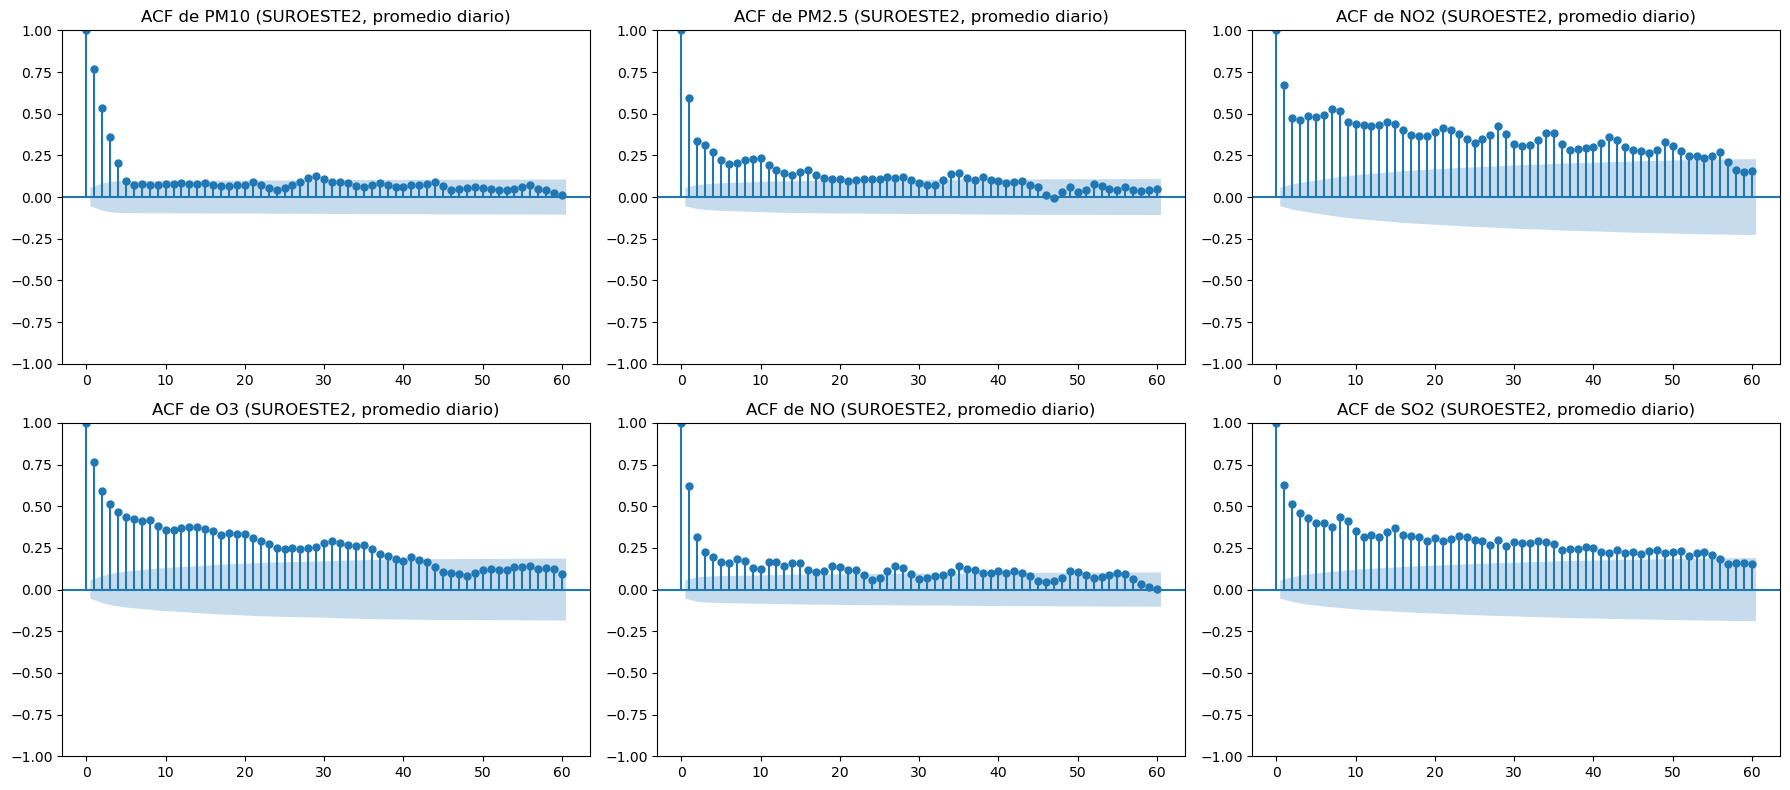

In [44]:
variables_analizar = ["PM10", "PM2.5", "NO2", "O3", "NO", "SO2"]

nrows, ncols = 2, 3  # 3 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()  # aplanar para indexado sencillo

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_22_25_diario.columns:
        serie = df_22_25_diario[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)
        ax.set_title(f"ACF de {var} (SUROESTE2, promedio diario)")
    else:
        ax.set_visible(False)

# Oculta ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### PACF

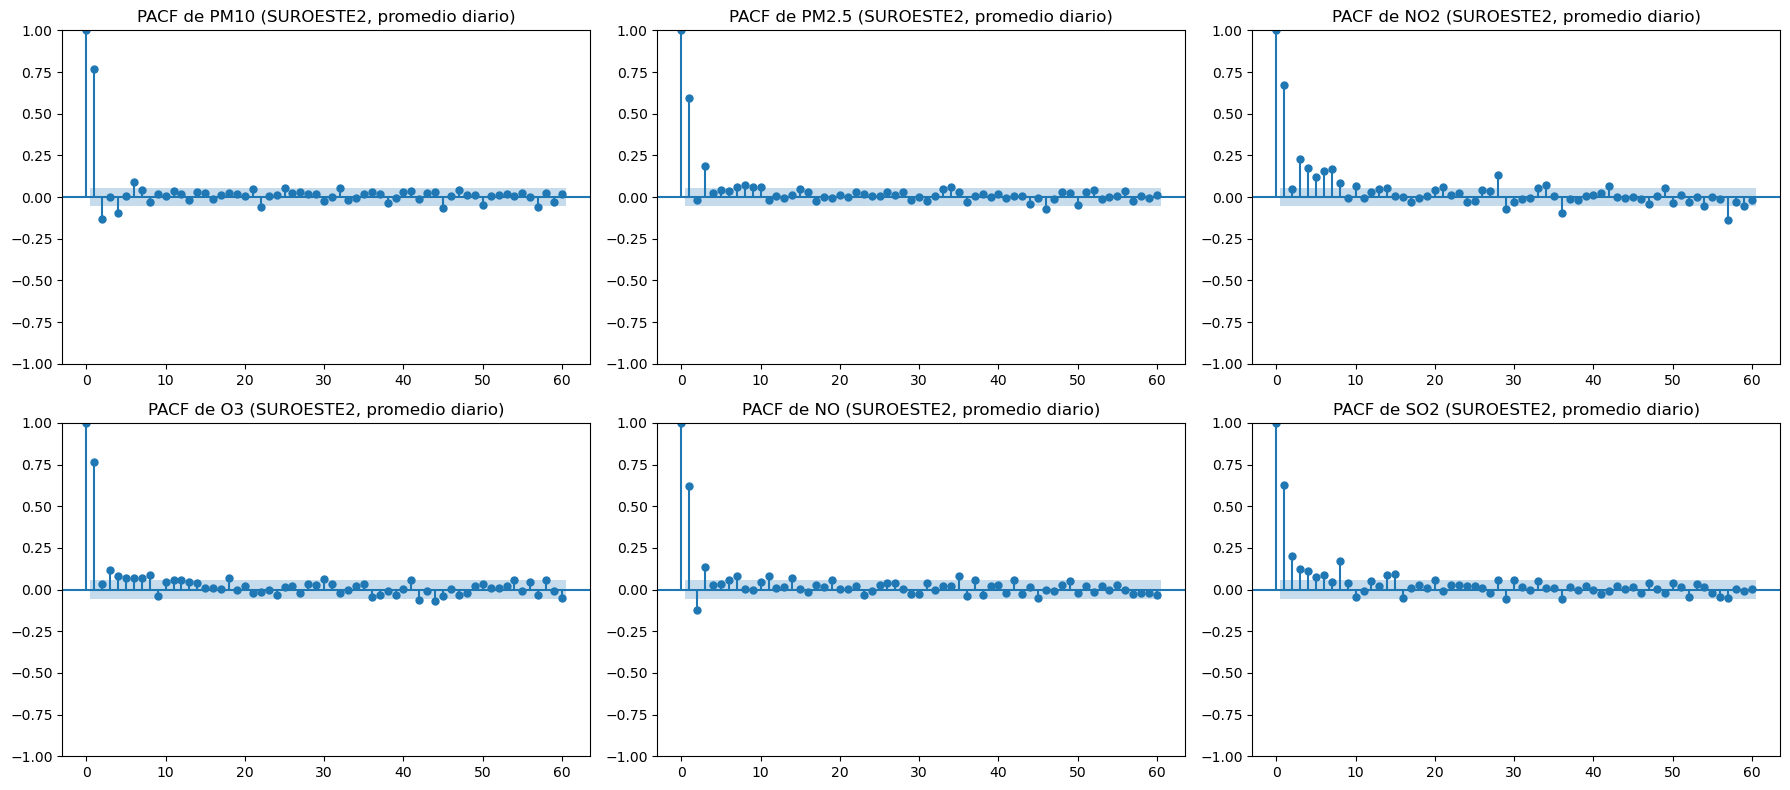

In [45]:
variables_analizar = ["PM10", "PM2.5", "NO2", "O3", "NO", "SO2"]

nrows, ncols = 2, 3  # 3 columnas x 2 filas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_22_25_diario.columns:
        serie = df_22_25_diario[var].dropna()
        plot_pacf(serie, ax=ax, lags=60, alpha=0.05, method='ywm')
        ax.set_title(f"PACF de {var} (SUROESTE2, promedio diario)")
    else:
        ax.set_visible(False)

# Ocultar ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Modelo

In [46]:
# --- Configuración Inicial ---
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

import os

contaminantes_lista = ["PM10", "PM2.5", "NO2", "O3", "NO", "SO2"]
meteo_cols = ["TOUT", "RH", "SR", "PRS"]

# Rangos para buscar el mejor modelo (Grid Search)
p_vals = [1, 2, 3] 
q_vals = [1, 2, 3]
d = 1
c = 1e-3  # Constante para evitar log(0)

resultados_finales = []
summary_dict = {}
graficas_path = "SUROESTE2_arimax_graficas"
os.makedirs(graficas_path, exist_ok=True)

resumen_lines = []
summary_lines = []

resumen_lines.append('Iniciando búsqueda de modelos ARIMAX para todos los contaminantes...\n')

for var in contaminantes_lista:
    if var not in df_22_25_diario.columns:
        mensaje = f"⚠️ Variable {var} no encontrada. Saltando..."
        resumen_lines.append(mensaje)
        continue
        
    mensaje = f"🔄 Procesando: {var}"
    resumen_lines.append(mensaje)
    
    # 1. Preparar datos (filtro y dropna)
    cols_necesarias = [var] + meteo_cols
    df_temp = df_22_25_diario[cols_necesarias].dropna()
    
    if df_temp.empty:
        mensaje = f"   Sin datos suficientes para {var}."
        resumen_lines.append(mensaje)
        continue
        
    # 2. Definir variables Endógena (y) y Exógenas (X)
    y_raw = df_temp[var]
    X = df_temp[meteo_cols]
    
    # Transformación Logarítmica
    y = np.log(y_raw + c)
    
    # Variables para guardar el mejor de este ciclo
    best_aic = np.inf
    best_order = None
    best_res = None
    
    # 3. Loop de Grid Search (p, q)
    for p in p_vals:
        for q in q_vals:
            try:
                model = ARIMA(y, exog=X, order=(p, d, q))
                res = model.fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_res = res
                    best_order = (p, d, q)
            except Exception:
                continue
    
    # 4. Guardar el ganador en la lista de resultados y la summary
    if best_res is not None:
        y_pred_log = best_res.fittedvalues
        y_pred_real = np.exp(y_pred_log) - c
        y_raw_alineado = y_raw.loc[y_pred_real.index]
        
        try:
            mape = mean_absolute_percentage_error(y_raw_alineado, y_pred_real)
        except Exception:
            mape = np.nan
        try:
            cme = mean_squared_error(y_raw_alineado, y_pred_real)
            rmse = np.sqrt(cme)
        except Exception:
            cme, rmse = np.nan, np.nan
        
        resultados_finales.append({
            "Variable": var,
            "Mejor_p": best_order[0],
            "Mejor_d": best_order[1],
            "Mejor_q": best_order[2],
            "AIC": best_aic,
            "BIC": best_res.bic,
            "Var_Residuos": np.var(best_res.resid),
            "MAPE": mape,
            "CME": cme,
            "RMSE": rmse
        })
        resumen_txt = (
            f"   ✅ Ganador {var}: ARIMA{best_order} | "
            f"AIC: {best_aic:.2f} | MAPE: {mape:.3%} | CME: {cme:.3f}\n"
        )
        resumen_lines.append(resumen_txt)
        
        summary_txt = f"\n--- Modelo {var} ---\n\n{best_res.summary()}\n"
        summary_lines.append(summary_txt)
        
        # Guardar la gráfica en vez de mostrarla
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        y.plot(ax=ax[0], label='Observado (log)', color='blue')
        y_pred_log.plot(ax=ax[0], label='Ajuste ARIMAX (log)', color='red', alpha=0.7)
        ax[0].set_title(f"{var} (log) Observado vs Ajustado")
        ax[0].legend()

        y_raw.plot(ax=ax[1], label='Observado', color='blue')
        y_pred_real.plot(ax=ax[1], label='Ajuste ARIMAX', color='red', alpha=0.7)
        ax[1].set_title(f"{var} Observado vs Ajustado (escala original)")
        ax[1].legend()
        plt.tight_layout()
        figpath = os.path.join(graficas_path, f"arimax_{var}.png")
        plt.savefig(figpath)
        plt.close(fig)
        
    else:
        msg_no_conv = f"   ❌ No se encontró convergencia para {var}"
        resumen_lines.append(msg_no_conv)

resumen_lines.append("\n--- PROCESO TERMINADO ---")

# Mostrar DataFrame final
df_resultados_arimax_todos = pd.DataFrame(resultados_finales)

if not df_resultados_arimax_todos.empty:
    resumen_lines.append('\nResumen de métricas seleccionadas:\n')
    resumen_lines.append(df_resultados_arimax_todos.to_string(index=False))
else:
    resumen_lines.append("No hubo resultados para mostrar.")

# Guardar todo en un archivo .txt para descarga
salida_txt = "\n".join(resumen_lines)
summary_txt_total = "\n".join(summary_lines)
with open("SUROESTE2_resumen_arimax_resultados.txt", "w", encoding="utf-8") as f:
    f.write(salida_txt)
    f.write('\n\n')
    f.write(summary_txt_total)

# Guardar DataFrame en Excel para descarga
df_resultados_arimax_todos.to_excel("SUROESTE2_resumen_arimax_resultados.xlsx", index=False)

# Instrucción para el usuario (no imprimir nada aquí)
# Los resultados y resúmenes están guardados en:
# - resumen_arimax_resultados.txt
# - resumen_arimax_resultados.xlsx
# - Carpeta 'arimax_graficas/' con las imágenes de los ajustes


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Industrial

### SURESTE3

In [47]:
df_22_25_diario = df_SURESTE3_22_25.copy()
df_22_25_diario.index = pd.to_datetime(df_22_25_diario.index)
df_22_25_diario = df_22_25_diario.resample("D").mean()
df_22_25_diario.describe().T

,count,mean,std,min,25%,50%,75%,max
CO,1277.0,1.354041,0.734329,0.000000,0.886667,1.321667,1.623750,9.153333
NO,1277.0,9.838524,12.180881,1.641667,3.533333,4.966667,10.154167,101.845833
NO2,1277.0,11.170382,6.652305,2.604167,6.166667,9.258333,14.695833,39.945833
O3,1277.0,26.365234,8.036027,4.937500,21.208333,25.541667,30.791667,61.020833
PM10,1277.0,68.326988,34.673176,15.583333,44.500000,59.791667,83.272727,264.291667
PM2.5,1277.0,20.487509,13.245854,3.937500,11.708333,17.000000,25.375000,150.041667
PRS,1277.0,728.318523,5.775650,701.512500,723.204167,728.820833,732.104167,748.125000
RH,1277.0,59.676421,14.756484,13.000000,50.291667,59.958333,69.416667,92.666667
SO2,1277.0,6.721953,4.697142,2.020833,3.991667,5.387500,7.870833,58.695833
SR,1277.0,0.148279,0.062856,0.000000,0.102500,0.153750,0.196667,0.295000


#### ACF

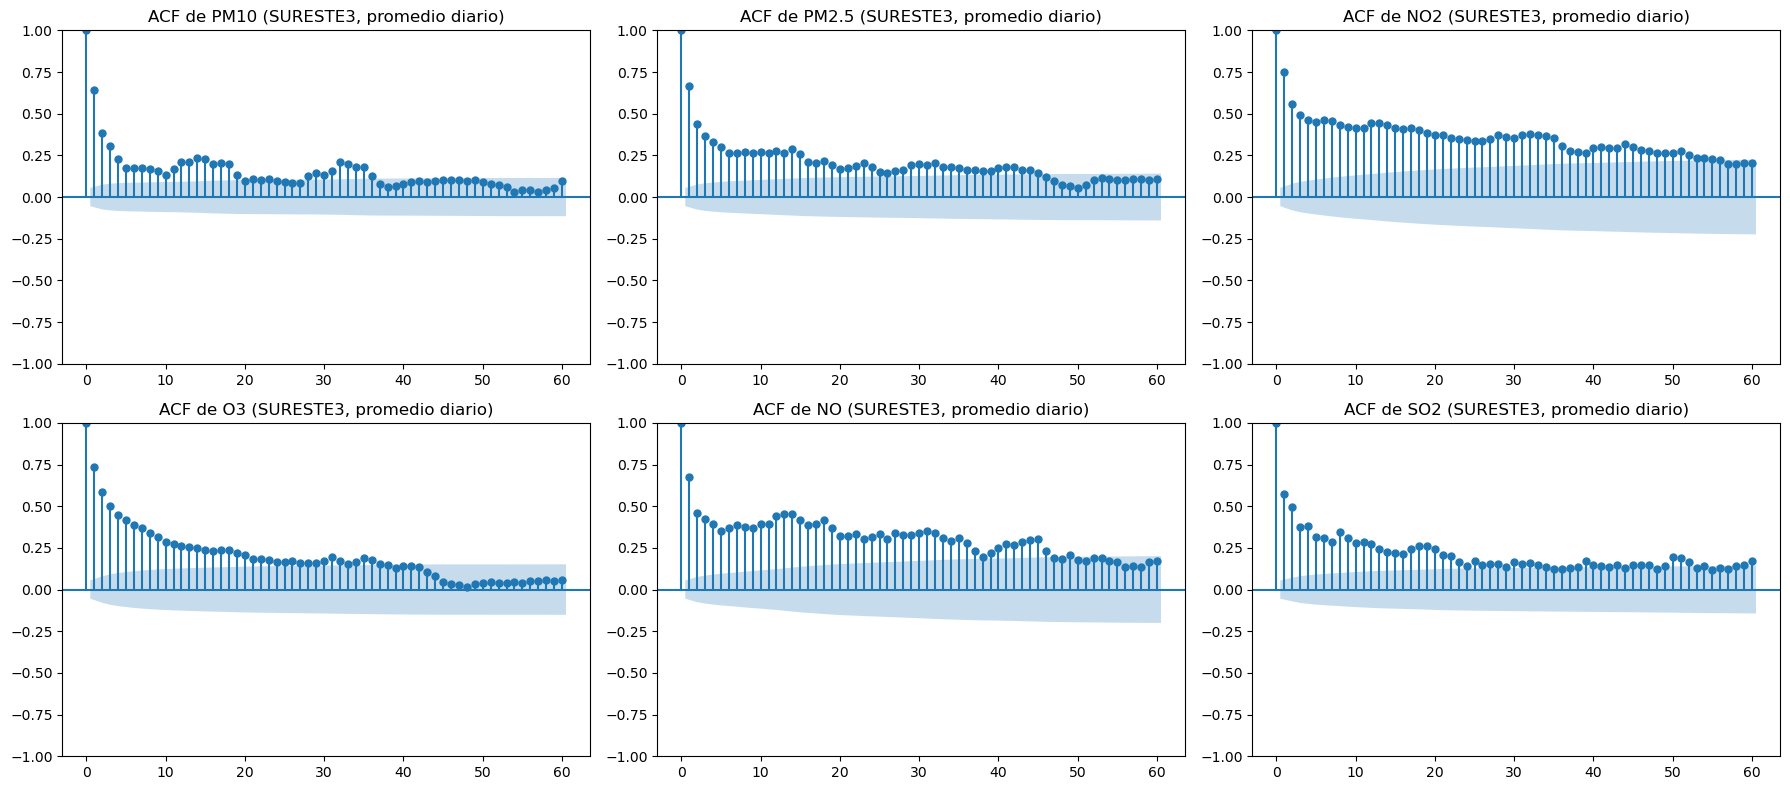

In [48]:
variables_analizar = ["PM10", "PM2.5", "NO2", "O3", "NO", "SO2"]

nrows, ncols = 2, 3  # 3 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()  

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_22_25_diario.columns:
        serie = df_22_25_diario[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)
        ax.set_title(f"ACF de {var} (SURESTE3, promedio diario)")
    else:
        ax.set_visible(False)

# Oculta ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


#### PACF

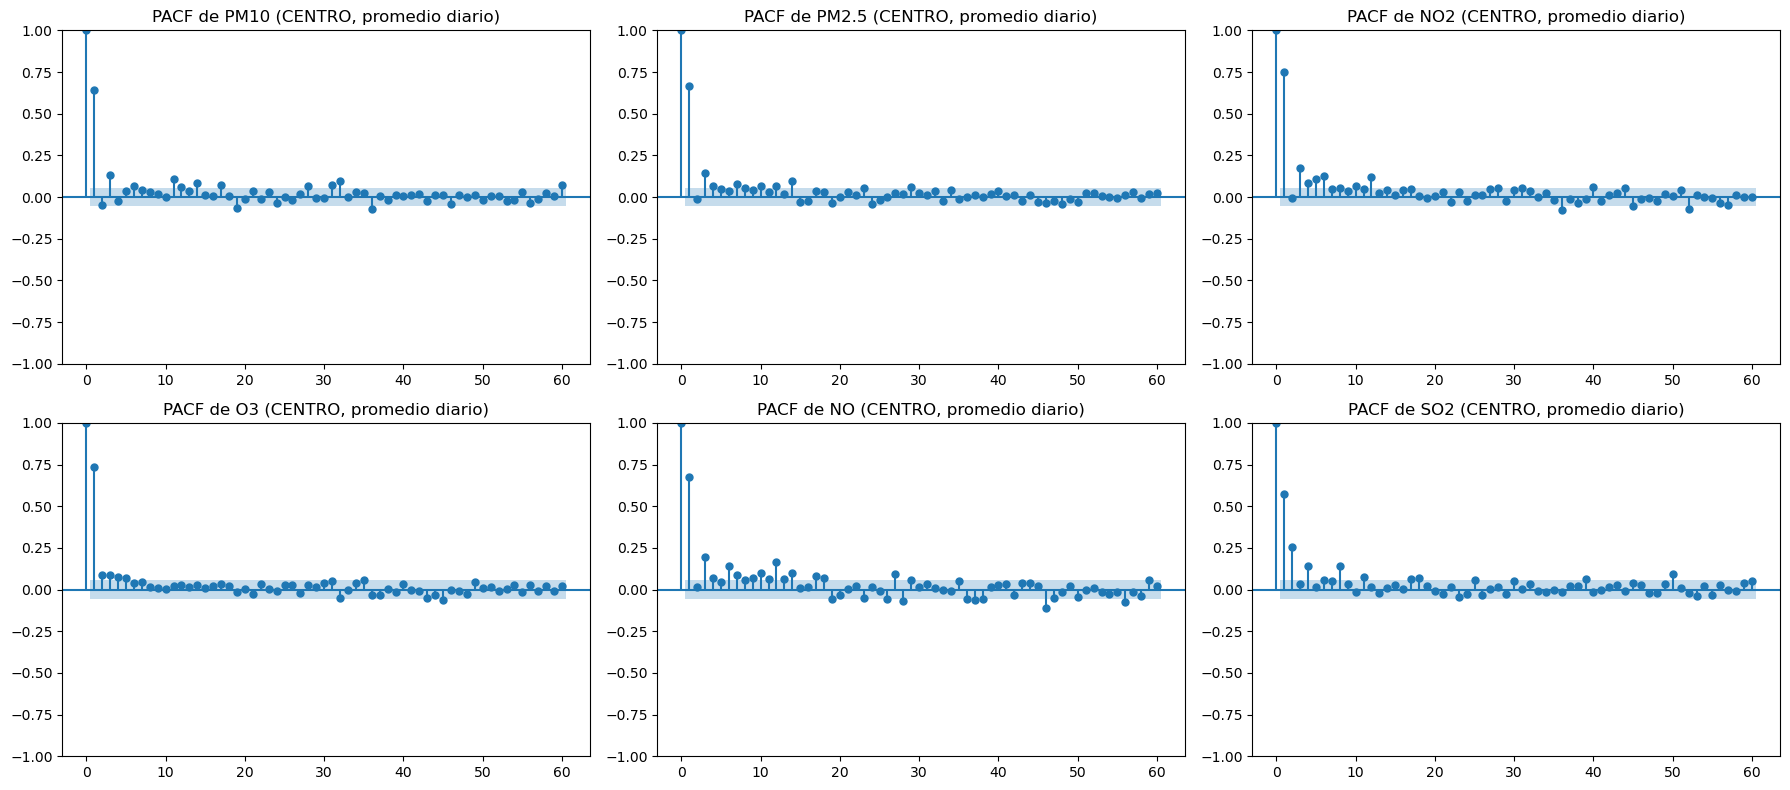

In [49]:
variables_analizar = ["PM10", "PM2.5", "NO2", "O3", "NO", "SO2"]

nrows, ncols = 2, 3  # 3 columnas x 2 filas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_22_25_diario.columns:
        serie = df_22_25_diario[var].dropna()
        plot_pacf(serie, ax=ax, lags=60, alpha=0.05, method='ywm')
        ax.set_title(f"PACF de {var} (CENTRO, promedio diario)")
    else:
        ax.set_visible(False)

# Ocultar ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


#### Modelo

In [50]:
# --- Configuración Inicial ---

contaminantes_lista = ["PM10", "PM2.5", "NO2", "O3", "NO", "SO2"]
meteo_cols = ["TOUT", "RH", "SR", "PRS"]

# Rangos para buscar el mejor modelo (Grid Search)
p_vals = [1, 2, 3] 
q_vals = [1, 2, 3]
d = 1
c = 1e-3  # Constante para evitar log(0)

resultados_finales = []
summary_dict = {}
graficas_path = "SURESTE3_arimax_graficas"
os.makedirs(graficas_path, exist_ok=True)

resumen_lines = []
summary_lines = []

resumen_lines.append('Iniciando búsqueda de modelos ARIMAX para todos los contaminantes...\n')

for var in contaminantes_lista:
    if var not in df_22_25_diario.columns:
        mensaje = f"⚠️ Variable {var} no encontrada. Saltando..."
        resumen_lines.append(mensaje)
        continue
        
    mensaje = f"🔄 Procesando: {var}"
    resumen_lines.append(mensaje)
    
    # 1. Preparar datos (filtro y dropna)
    cols_necesarias = [var] + meteo_cols
    df_temp = df_22_25_diario[cols_necesarias].dropna()
    
    if df_temp.empty:
        mensaje = f"   Sin datos suficientes para {var}."
        resumen_lines.append(mensaje)
        continue
        
    # 2. Definir variables Endógena (y) y Exógenas (X)
    y_raw = df_temp[var]
    X = df_temp[meteo_cols]
    
    # Transformación Logarítmica
    y = np.log(y_raw + c)
    
    # Variables para guardar el mejor de este ciclo
    best_aic = np.inf
    best_order = None
    best_res = None
    
    # 3. Loop de Grid Search (p, q)
    for p in p_vals:
        for q in q_vals:
            try:
                model = ARIMA(y, exog=X, order=(p, d, q))
                res = model.fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_res = res
                    best_order = (p, d, q)
            except Exception:
                continue
    
    # 4. Guardar el ganador en la lista de resultados y la summary
    if best_res is not None:
        y_pred_log = best_res.fittedvalues
        y_pred_real = np.exp(y_pred_log) - c
        y_raw_alineado = y_raw.loc[y_pred_real.index]
        
        try:
            mape = mean_absolute_percentage_error(y_raw_alineado, y_pred_real)
        except Exception:
            mape = np.nan
        try:
            cme = mean_squared_error(y_raw_alineado, y_pred_real)
            rmse = np.sqrt(cme)
        except Exception:
            cme, rmse = np.nan, np.nan
        
        resultados_finales.append({
            "Variable": var,
            "Mejor_p": best_order[0],
            "Mejor_d": best_order[1],
            "Mejor_q": best_order[2],
            "AIC": best_aic,
            "BIC": best_res.bic,
            "Var_Residuos": np.var(best_res.resid),
            "MAPE": mape,
            "CME": cme,
            "RMSE": rmse
        })
        resumen_txt = (
            f"   ✅ Ganador {var}: ARIMA{best_order} | "
            f"AIC: {best_aic:.2f} | MAPE: {mape:.3%} | CME: {cme:.3f}\n"
        )
        resumen_lines.append(resumen_txt)
        
        summary_txt = f"\n--- Modelo {var} ---\n\n{best_res.summary()}\n"
        summary_lines.append(summary_txt)
        
        # Guardar la gráfica en vez de mostrarla
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        y.plot(ax=ax[0], label='Observado (log)', color='blue')
        y_pred_log.plot(ax=ax[0], label='Ajuste ARIMAX (log)', color='red', alpha=0.7)
        ax[0].set_title(f"{var} (log) Observado vs Ajustado")
        ax[0].legend()

        y_raw.plot(ax=ax[1], label='Observado', color='blue')
        y_pred_real.plot(ax=ax[1], label='Ajuste ARIMAX', color='red', alpha=0.7)
        ax[1].set_title(f"{var} Observado vs Ajustado (escala original)")
        ax[1].legend()
        plt.tight_layout()
        figpath = os.path.join(graficas_path, f"arimax_{var}.png")
        plt.savefig(figpath)
        plt.close(fig)
        
    else:
        msg_no_conv = f"   ❌ No se encontró convergencia para {var}"
        resumen_lines.append(msg_no_conv)

resumen_lines.append("\n--- PROCESO TERMINADO ---")

# Mostrar DataFrame final
df_resultados_arimax_todos = pd.DataFrame(resultados_finales)

if not df_resultados_arimax_todos.empty:
    resumen_lines.append('\nResumen de métricas seleccionadas:\n')
    resumen_lines.append(df_resultados_arimax_todos.to_string(index=False))
else:
    resumen_lines.append("No hubo resultados para mostrar.")

# Guardar todo en un archivo .txt para descarga
salida_txt = "\n".join(resumen_lines)
summary_txt_total = "\n".join(summary_lines)
with open("SURESTE3_resumen_arimax_resultados.txt", "w", encoding="utf-8") as f:
    f.write(salida_txt)
    f.write('\n\n')
    f.write(summary_txt_total)

# Guardar DataFrame en Excel para descarga
df_resultados_arimax_todos.to_excel("SURESTE3_resumen_arimax_resultados.xlsx", index=False)


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### NORTE 2

In [51]:
df_22_25_diario = df_NORTE2_22_25.copy()
df_22_25_diario.index = pd.to_datetime(df_22_25_diario.index)
df_22_25_diario = df_22_25_diario.resample("D").mean()
df_22_25_diario.describe().T

,count,mean,std,min,25%,50%,75%,max
CO,1277.0,1.126756,0.462281,0.005833,0.872917,1.042083,1.342917,3.180000
NO,1277.0,22.007082,16.742832,2.737500,10.079167,16.425000,28.329167,130.645833
NO2,1277.0,24.707027,10.140976,5.687500,16.529167,22.895833,30.783333,68.387500
O3,1277.0,24.375347,8.588382,2.208333,18.666667,23.791667,29.333333,56.625000
PM10,1277.0,66.579798,31.321534,9.208333,45.625000,60.541667,80.375000,291.625000
PM2.5,1277.0,20.140836,9.347812,2.791667,13.500000,18.500000,25.041667,99.833333
PRS,1277.0,712.720229,3.818074,695.479167,710.233333,712.379167,714.870833,726.095833
RH,1277.0,54.544782,15.465329,8.958333,45.375000,55.000000,64.291667,90.000000
SO2,1277.0,4.644225,1.613734,1.954167,3.512500,4.275000,5.522917,16.927083
SR,1277.0,0.123256,0.050743,0.007500,0.093333,0.128333,0.165000,0.213750


#### ACF

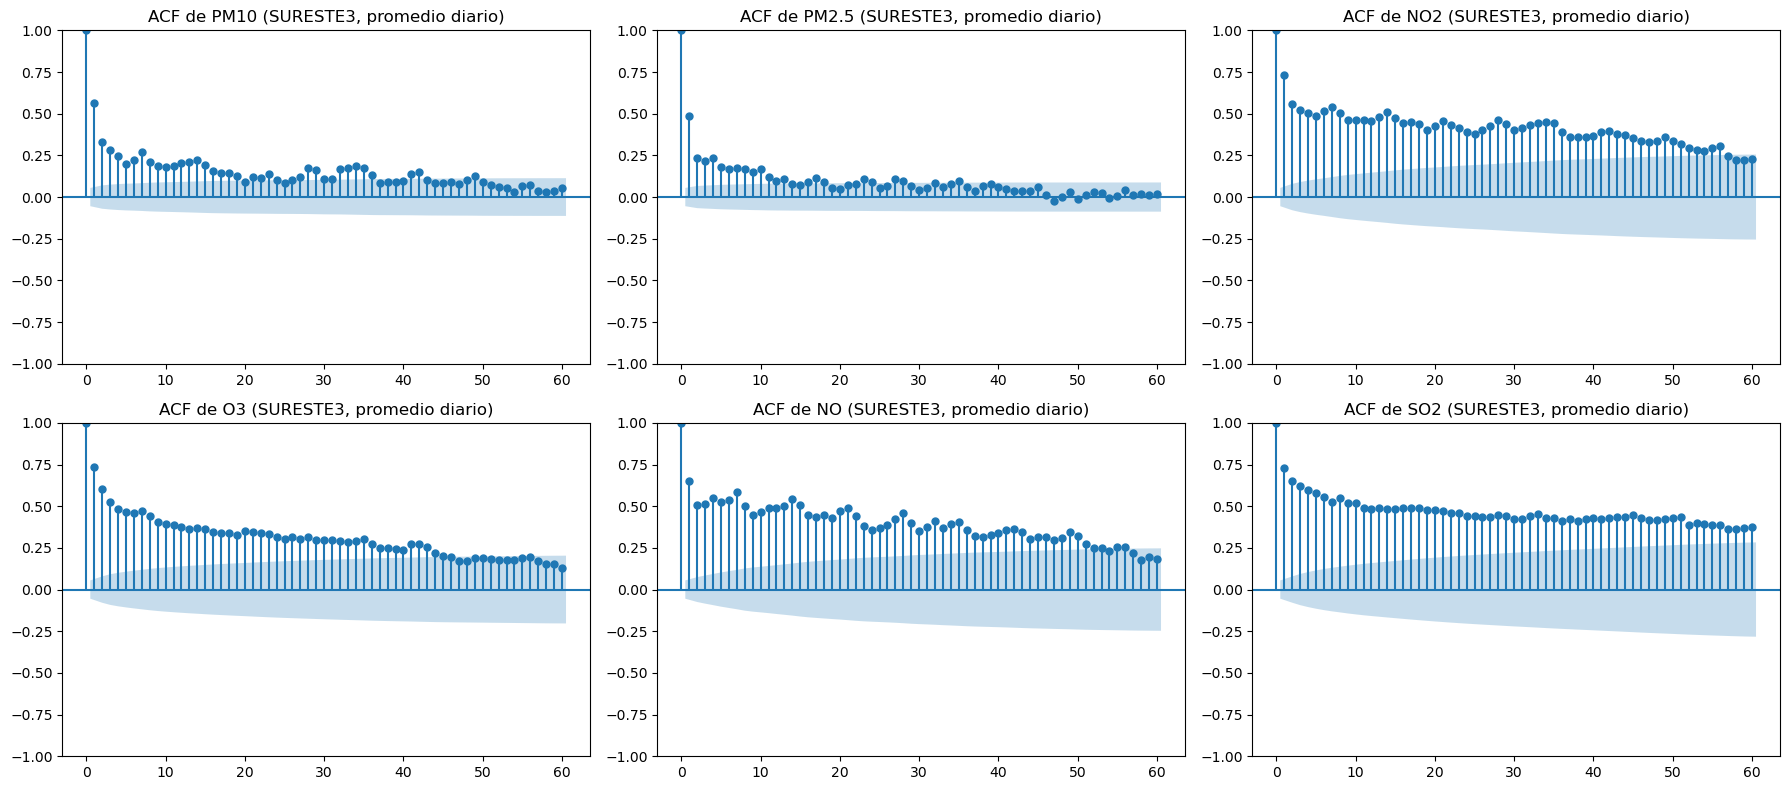

In [ ]:
variables_analizar = ["PM10", "PM2.5", "NO2", "O3", "NO", "SO2"]

nrows, ncols = 2, 3  # 3 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()  

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_22_25_diario.columns:
        serie = df_22_25_diario[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)
        ax.set_title(f"ACF de {var} (NORTE2, promedio diario)")
    else:
        ax.set_visible(False)

# Oculta ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


#### PACF

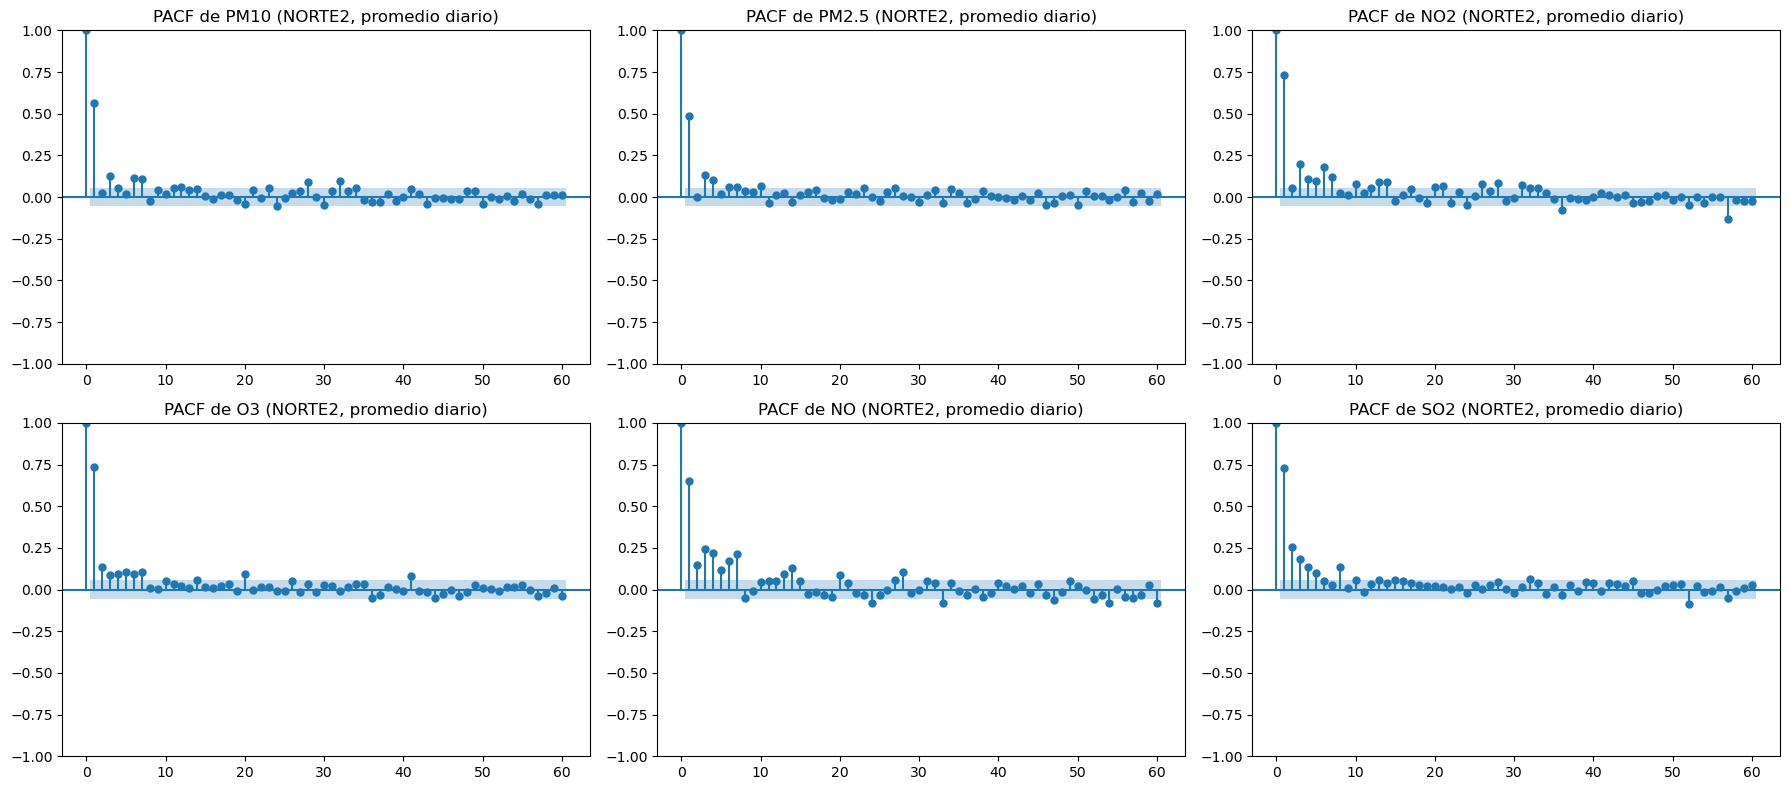

In [54]:
variables_analizar = ["PM10", "PM2.5", "NO2", "O3", "NO", "SO2"]

nrows, ncols = 2, 3  # 3 columnas x 2 filas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_22_25_diario.columns:
        serie = df_22_25_diario[var].dropna()
        plot_pacf(serie, ax=ax, lags=60, alpha=0.05, method='ywm')
        ax.set_title(f"PACF de {var} (NORTE2, promedio diario)")
    else:
        ax.set_visible(False)

# Ocultar ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Modelo

In [55]:
# --- Configuración Inicial ---
contaminantes_lista = ["PM10", "PM2.5", "NO2", "O3", "NO", "SO2"]
meteo_cols = ["TOUT", "RH", "SR", "PRS"]

# Rangos para buscar el mejor modelo (Grid Search)
p_vals = [1, 2, 3] 
q_vals = [1, 2, 3]
d = 1
c = 1e-3  # Constante para evitar log(0)

resultados_finales = []
summary_dict = {}
graficas_path = "NORTE2_arimax_graficas"
os.makedirs(graficas_path, exist_ok=True)

resumen_lines = []
summary_lines = []

resumen_lines.append('Iniciando búsqueda de modelos ARIMAX para todos los contaminantes...\n')

for var in contaminantes_lista:
    if var not in df_22_25_diario.columns:
        mensaje = f"⚠️ Variable {var} no encontrada. Saltando..."
        resumen_lines.append(mensaje)
        continue
        
    mensaje = f"🔄 Procesando: {var}"
    resumen_lines.append(mensaje)
    
    # 1. Preparar datos (filtro y dropna)
    cols_necesarias = [var] + meteo_cols
    df_temp = df_22_25_diario[cols_necesarias].dropna()
    
    if df_temp.empty:
        mensaje = f"   Sin datos suficientes para {var}."
        resumen_lines.append(mensaje)
        continue
        
    # 2. Definir variables Endógena (y) y Exógenas (X)
    y_raw = df_temp[var]
    X = df_temp[meteo_cols]
    
    # Transformación Logarítmica
    y = np.log(y_raw + c)
    
    # Variables para guardar el mejor de este ciclo
    best_aic = np.inf
    best_order = None
    best_res = None
    
    # 3. Loop de Grid Search (p, q)
    for p in p_vals:
        for q in q_vals:
            try:
                model = ARIMA(y, exog=X, order=(p, d, q))
                res = model.fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_res = res
                    best_order = (p, d, q)
            except Exception:
                continue
    
    # 4. Guardar el ganador en la lista de resultados y la summary
    if best_res is not None:
        y_pred_log = best_res.fittedvalues
        y_pred_real = np.exp(y_pred_log) - c
        y_raw_alineado = y_raw.loc[y_pred_real.index]
        
        try:
            mape = mean_absolute_percentage_error(y_raw_alineado, y_pred_real)
        except Exception:
            mape = np.nan
        try:
            cme = mean_squared_error(y_raw_alineado, y_pred_real)
            rmse = np.sqrt(cme)
        except Exception:
            cme, rmse = np.nan, np.nan
        
        resultados_finales.append({
            "Variable": var,
            "Mejor_p": best_order[0],
            "Mejor_d": best_order[1],
            "Mejor_q": best_order[2],
            "AIC": best_aic,
            "BIC": best_res.bic,
            "Var_Residuos": np.var(best_res.resid),
            "MAPE": mape,
            "CME": cme,
            "RMSE": rmse
        })
        resumen_txt = (
            f"   ✅ Ganador {var}: ARIMA{best_order} | "
            f"AIC: {best_aic:.2f} | MAPE: {mape:.3%} | CME: {cme:.3f}\n"
        )
        resumen_lines.append(resumen_txt)
        
        summary_txt = f"\n--- Modelo {var} ---\n\n{best_res.summary()}\n"
        summary_lines.append(summary_txt)
        
        # Guardar la gráfica en vez de mostrarla
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        y.plot(ax=ax[0], label='Observado (log)', color='blue')
        y_pred_log.plot(ax=ax[0], label='Ajuste ARIMAX (log)', color='red', alpha=0.7)
        ax[0].set_title(f"{var} (log) Observado vs Ajustado")
        ax[0].legend()

        y_raw.plot(ax=ax[1], label='Observado', color='blue')
        y_pred_real.plot(ax=ax[1], label='Ajuste ARIMAX', color='red', alpha=0.7)
        ax[1].set_title(f"{var} Observado vs Ajustado (escala original)")
        ax[1].legend()
        plt.tight_layout()
        figpath = os.path.join(graficas_path, f"arimax_{var}.png")
        plt.savefig(figpath)
        plt.close(fig)
        
    else:
        msg_no_conv = f"   ❌ No se encontró convergencia para {var}"
        resumen_lines.append(msg_no_conv)

resumen_lines.append("\n--- PROCESO TERMINADO ---")

# Mostrar DataFrame final
df_resultados_arimax_todos = pd.DataFrame(resultados_finales)

if not df_resultados_arimax_todos.empty:
    resumen_lines.append('\nResumen de métricas seleccionadas:\n')
    resumen_lines.append(df_resultados_arimax_todos.to_string(index=False))
else:
    resumen_lines.append("No hubo resultados para mostrar.")

# Guardar todo en un archivo .txt para descarga
salida_txt = "\n".join(resumen_lines)
summary_txt_total = "\n".join(summary_lines)
with open("NORTE2_resumen_arimax_resultados.txt", "w", encoding="utf-8") as f:
    f.write(salida_txt)
    f.write('\n\n')
    f.write(summary_txt_total)

# Guardar DataFrame en Excel para descarga
df_resultados_arimax_todos.to_excel("NORTE2_resumen_arimax_resultados.xlsx", index=False)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gabrielvas/anaconda3/envs/tecmx2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


# Análisis

## Comparaciones

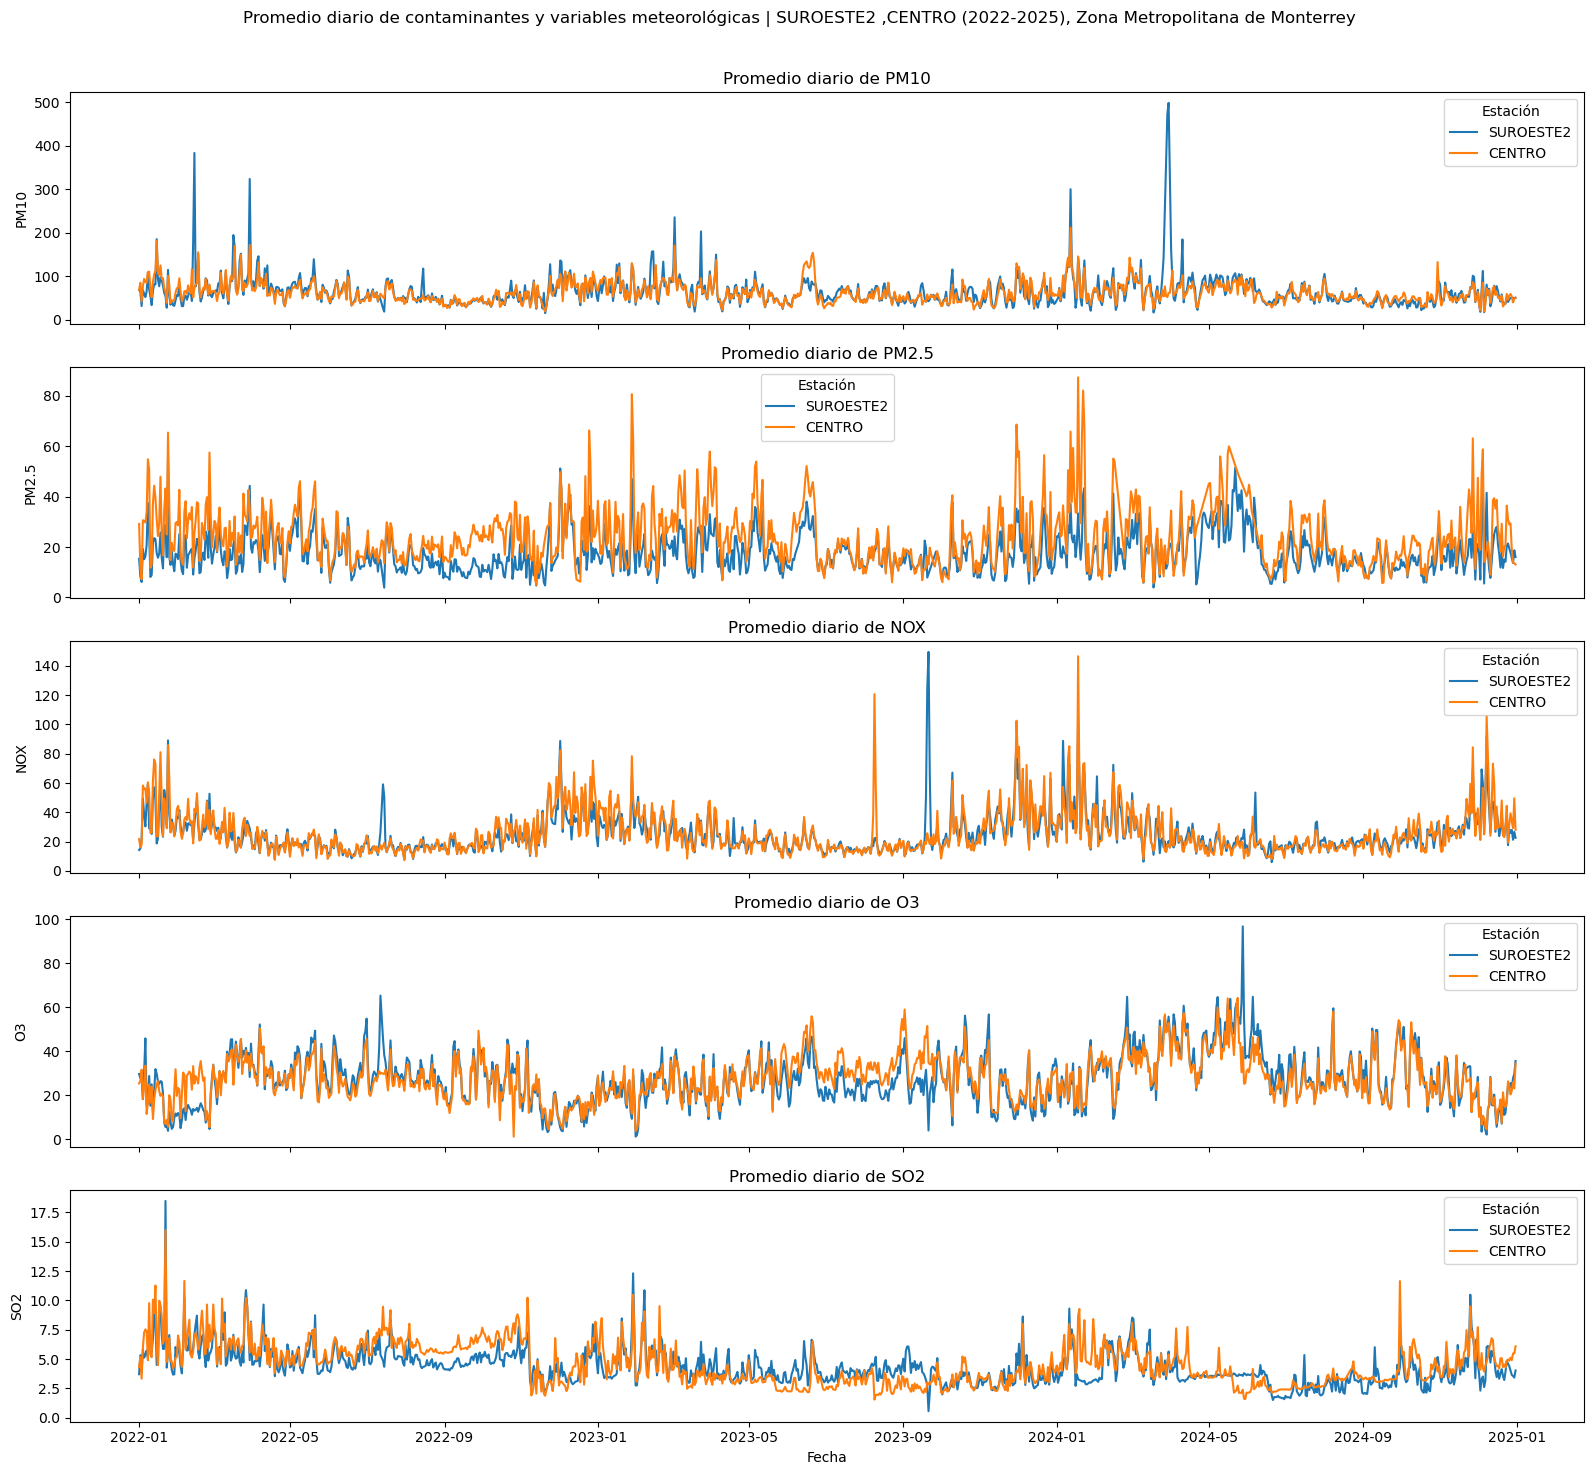

In [18]:

contaminantes = ["PM10", "PM2.5", "NOX", "O3", "SO2"]
#meteo = ["TOUT", "RH", "SR", "PRS"]
vars_plot = contaminantes # + meteo
estaciones1 = ["SUROESTE2", "CENTRO"]


df_all = None
for estacion in estaciones1:
    df_est = df_22_25_by_station[estacion].copy()
    df_est.index = pd.to_datetime(df_est.index)
    dfd = df_est[ [col for col in df_est.columns if col.upper() in [v.upper() for v in vars_plot]] ].resample("D").mean()
    dfd.columns = [f"{estacion}_{col}" for col in dfd.columns]
    df_all = dfd if df_all is None else pd.concat([df_all, dfd], axis=1)

nrows = len(vars_plot)
fig, axes = plt.subplots(nrows, 1, figsize=(16, 3 * nrows), sharex=True)

for i, var in enumerate(vars_plot):
    ax = axes[i] if nrows > 1 else axes
    for estacion in estaciones1:
        colname = f"{estacion}_{var}"
        if colname in df_all.columns:
            ax.plot(df_all.index, df_all[colname], label=estacion)
    ax.set_ylabel(f"{var}")
    ax.legend(title="Estación")
    ax.set_title(f"Promedio diario de {var}")

axes[-1].set_xlabel("Fecha")
plt.suptitle(f"Promedio diario de contaminantes y variables meteorológicas | {' ,'.join(estaciones1)} (2022-2025), Zona Metropolitana de Monterrey")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()




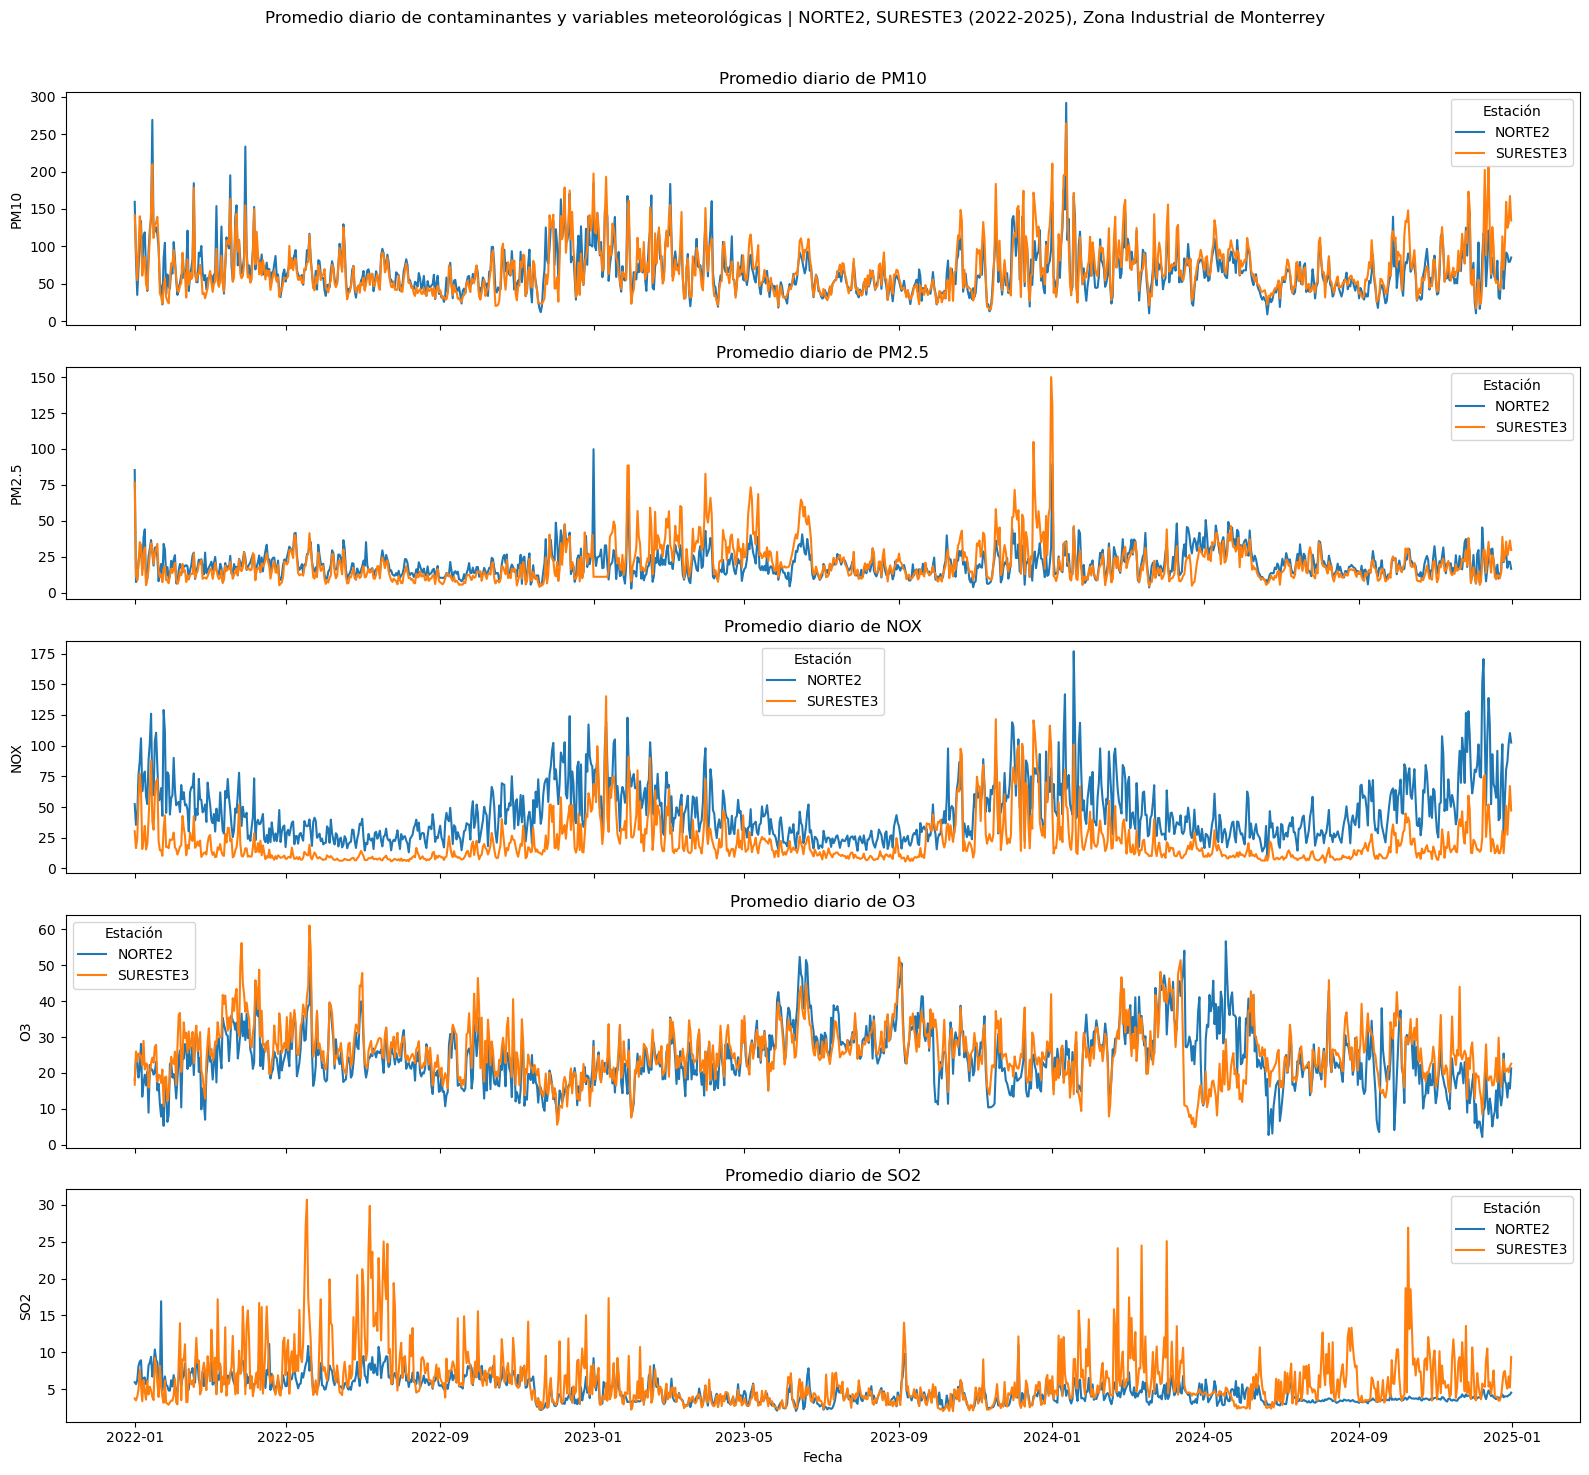

In [19]:

contaminantes = ["PM10", "PM2.5", "NOX", "O3", "SO2"]
#meteo = ["TOUT", "RH", "SR", "PRS"]
vars_plot = contaminantes #+ meteo
estaciones1 = ["NORTE2", "SURESTE3"]

# Crear un DataFrame resumen para todos los contaminantes y meteorológicos por estación, por día
# Cada columna será "estacion_variable", filas por fecha. Así permite graficar todo junto.
df_all = None
for estacion in estaciones1:
    df_est = df_22_25_by_station[estacion].copy()
    df_est.index = pd.to_datetime(df_est.index)
    dfd = df_est[ [col for col in df_est.columns if col.upper() in [v.upper() for v in vars_plot]] ].resample("D").mean()
    dfd.columns = [f"{estacion}_{col}" for col in dfd.columns]
    df_all = dfd if df_all is None else pd.concat([df_all, dfd], axis=1)

# Graficar en una sola hoja, 1 fila por variable (contaminantes y meteorológicos)
nrows = len(vars_plot)
fig, axes = plt.subplots(nrows, 1, figsize=(16, 3 * nrows), sharex=True)

for i, var in enumerate(vars_plot):
    ax = axes[i] if nrows > 1 else axes
    for estacion in estaciones1:
        colname = f"{estacion}_{var}"
        if colname in df_all.columns:
            ax.plot(df_all.index, df_all[colname], label=estacion)
    ax.set_ylabel(f"{var}")
    ax.legend(title="Estación")
    ax.set_title(f"Promedio diario de {var}")

axes[-1].set_xlabel("Fecha")
plt.suptitle(f"Promedio diario de contaminantes y variables meteorológicas | {', '.join(estaciones1)} (2022-2025), Zona Industrial de Monterrey")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
